## Setup, Requirements, and Configuration

In [5]:
import matplotlib as mpl
print(mpl.rcParams['font.family'])
print(mpl.rcParams['font.sans-serif'])

['serif']
['DejaVu Sans', 'Bitstream Vera Sans', 'Computer Modern Sans Serif', 'Lucida Grande', 'Verdana', 'Geneva', 'Lucid', 'Arial', 'Helvetica', 'Avant Garde', 'sans-serif']


In [1]:
#!/usr/bin/env python3
from __future__ import annotations

# Standard libraries
import pandas as pd
import numpy as np
import seaborn as sns
import math
import os
import csv

# For date handling
from datetime import datetime, timedelta
from dataclasses import dataclass
# For type hints
from pathlib import Path
from typing import Dict, List, Tuple
# For plotting
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MonthLocator 
from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba
from matplotlib.ticker import ScalarFormatter, FuncFormatter

# For data loading and analysis
from scipy.io import loadmat, whosmat
from scipy.stats import rankdata, pearsonr
from scipy.integrate import solve_ivp


# Suppress specific warnings for cleaner output
import warnings
warnings.filterwarnings('ignore', category=UserWarning)


# --- Global Manuscript Styling ---
plt.rcParams.update({
    "font.family": "serif",        
    "mathtext.fontset": "cm",
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.titlesize": 22,    # Large titles
    "axes.labelsize": 18,    # Large labels
    "xtick.labelsize": 16,   # Large ticks
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "axes.linewidth": 1.5,   
    "axes.spines.top": True,   # Box ON
    "axes.spines.right": True, # Box ON
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "savefig.dpi": 600         
})

# --- Constants & Folder Creation ---
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "Figures2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True) 

ROOT_DIR = Path.cwd()
DATA_DIR = ROOT_DIR / "Data"

# Country list matching your folder structure
COUNTRIES = [
    ("South Korea", DATA_DIR / "Korea"),
    ("Japan", DATA_DIR / "Japan"),
    ("Pakistan", DATA_DIR / "Pakistan"),
]

# Scenario and wave labels
SCENARIO_ORDER = ("Early intervention", "Late intervention")
WAVE_COLUMNS = ("Wave1", "Wave2", "Wave3")
WAVE_LABELS = ("Wave1", "Wave2", "Wave3") 

@dataclass
class PolicyData:
    averages: np.ndarray
    per_wave: np.ndarray

@dataclass
class ParameterData:
    beta_f: np.ndarray
    mu_f: np.ndarray

# Config for Cell 3
EXCEL_CONFIG = {
    'South Korea': {'path': DATA_DIR / 'Coviddata-korea1.xlsx', 'date_column': 'date', 'wave_ranges': [(27, 204), (204, 296), (296, 391)]},
    'Japan': {'path': DATA_DIR / 'covid_data-japan1.xlsx', 'date_column': 'date', 'wave_ranges': [(50, 160), (160, 275), (275, 391)]},
    'Pakistan': {'path': DATA_DIR / 'covid_data-pak1.xlsx', 'date_column': 'date', 'wave_ranges': [(20, 230), (230, 375), (375, 480)]},
}

def normalize_time_vector(tv):
    if tv is None or len(tv) == 0: return []
    arr = np.asarray(tv).flatten()
    if np.issubdtype(arr.dtype, np.number) and arr[0] > 700000:
        return [datetime.fromordinal(int(d)) + timedelta(days=d%1) - timedelta(days=366) for d in arr]
    # Assume days from 2020-01-01 if small numbers
    start_date = datetime(2020, 1, 1)
    return [start_date + timedelta(days=int(d)) for d in arr]


def _normalize_dates(arr):
    """Normalize various date vector formats to a Python datetime list.

    Handles MATLAB date vectors/numerical datenums (large numbers), arrays
    of datetimes or date strings, and returns a list of Python datetimes.
    """
    if arr is None:
        return []
    try:
        flat = np.asarray(arr).flatten()
    except Exception:
        return []

    # MATLAB datenum (large values)
    if flat.size > 0 and np.issubdtype(flat.dtype, np.number) and flat[0] > 700000:
        return normalize_time_vector(flat)

    # Try pandas conversion for string-like or datetime-like arrays
    try:
        series = pd.to_datetime(flat)
        return [pd.Timestamp(x).to_pydatetime() for x in series]
    except Exception:
        out = []
        for el in flat:
            if isinstance(el, (datetime, pd.Timestamp, np.datetime64)):
                out.append(pd.to_datetime(el).to_pydatetime())
            else:
                try:
                    out.append(pd.to_datetime(el))
                except Exception:
                    # skip unparseable entries
                    pass
        return out


def _combine_dates(d1, d2, d3):
    """Combine up to three date sequences, offsetting later sequences if
    they overlap with prior sequences so the combined timeline is sequential.
    """
    def _ensure(seq):
        return list(seq) if seq is not None else []

    parts = [_ensure(d1), _ensure(d2), _ensure(d3)]
    combined = []
    prev = None
    for seq in parts:
        if not seq:
            continue
        if prev is None or seq[0] > prev:
            combined.extend(seq)
        else:
            offset = (prev - seq[0]) + timedelta(days=1)
            combined.extend([s + offset for s in seq])
        prev = combined[-1]
    return combined
print("Setup complete. Ready to load data and generate figures.")

Setup complete. Ready to load data and generate figures.


In [2]:
import matplotlib
import matplotlib.pyplot as plt

print(matplotlib.__version__)



3.11.0


In [3]:
# Verify wave date ranges for all countries

for country in EXCEL_CONFIG:
    cfg = EXCEL_CONFIG[country]
    print(f"\n--- {country} ---")
    try:
        df = pd.read_excel(cfg['path'])
        dates = pd.to_datetime(df[cfg['date_column']])
    except Exception as e:
        print(f"Error reading Excel for {country}: {e}")
        continue

    slices = []
    for k, (start, end) in enumerate(cfg['wave_ranges'], 1):
        start_idx = start - 1
        length = end - start + 1
        # guard slicing bounds
        if start_idx < 0 or start_idx + length > len(dates):
            print(f" Wave {k}: MATLAB {start}:{end} -> slice out of bounds (Excel length {len(dates)})")
            continue
        sl = dates.iloc[start_idx : start_idx + length]
        slices.append(sl)
        print(f" Wave {k}: MATLAB {start}:{end} -> {sl.iloc[0].strftime('%d-%b-%Y')} to {sl.iloc[-1].strftime('%d-%b-%Y')}")

    if not slices:
        print(' No valid waves found.')
        continue

    combined = pd.concat(slices)
    combined_start = combined.iloc[0].strftime('%d-%b-%Y')
    combined_end = combined.iloc[-1].strftime('%d-%b-%Y')
    print(f" Combined Excel date range: {combined_start} to {combined_end}")

    # Compare to MAT Date_combined if available
    
    mat_path = DATA_DIR / country.split()[0] / f"{country.split()[0]}Data.mat"
    if mat_path.exists():
        try:
            mat = loadmat(mat_path)
            if 'Date_combined' in mat:
                # Normalize MATLAB date vector using existing helper
                mat_dates = _normalize_dates(mat['Date_combined'].flatten())
                if mat_dates:
                    mat_start = pd.to_datetime(mat_dates[0]).strftime('%d-%b-%Y')
                    mat_end = pd.to_datetime(mat_dates[-1]).strftime('%d-%b-%Y')
                    print(f" MATLAB Date_combined range: {mat_start} to {mat_end}")
                    if (combined_start == mat_start) and (combined_end == mat_end):
                        print(' ✅ Excel combined range matches MATLAB Date_combined')
                    else:
                        print(' ⚠️ Excel combined range DOES NOT match MATLAB Date_combined')
                else:
                    print(' MATLAB Date_combined present but could not be parsed')
            else:
                print(' No Date_combined in MAT file to compare')
        except Exception as e:
            print(f"Error reading MAT for {country}: {e}")
    else:
        print(' No MAT file found to compare')
        # print("matlab data",mat_path)


--- South Korea ---
 Wave 1: MATLAB 27:204 -> 16-Feb-2020 to 11-Aug-2020
 Wave 2: MATLAB 204:296 -> 11-Aug-2020 to 11-Nov-2020
 Wave 3: MATLAB 296:391 -> 11-Nov-2020 to 14-Feb-2021
 Combined Excel date range: 16-Feb-2020 to 14-Feb-2021
 No MAT file found to compare

--- Japan ---
 Wave 1: MATLAB 50:160 -> 10-Mar-2020 to 28-Jun-2020
 Wave 2: MATLAB 160:275 -> 28-Jun-2020 to 21-Oct-2020
 Wave 3: MATLAB 275:391 -> 21-Oct-2020 to 14-Feb-2021
 Combined Excel date range: 10-Mar-2020 to 14-Feb-2021
 No Date_combined in MAT file to compare

--- Pakistan ---
 Wave 1: MATLAB 20:230 -> 17-Mar-2020 to 13-Oct-2020
 Wave 2: MATLAB 230:375 -> 13-Oct-2020 to 07-Mar-2021
 Wave 3: MATLAB 375:480 -> 07-Mar-2021 to 20-Jun-2021
 Combined Excel date range: 17-Mar-2020 to 20-Jun-2021
 No Date_combined in MAT file to compare


## Graphical abstract summarizing Ensemble Kalman Particle Filter (EnKPF) results across South Korea, Japan, and Pakistan.

Data Processing and Plotting

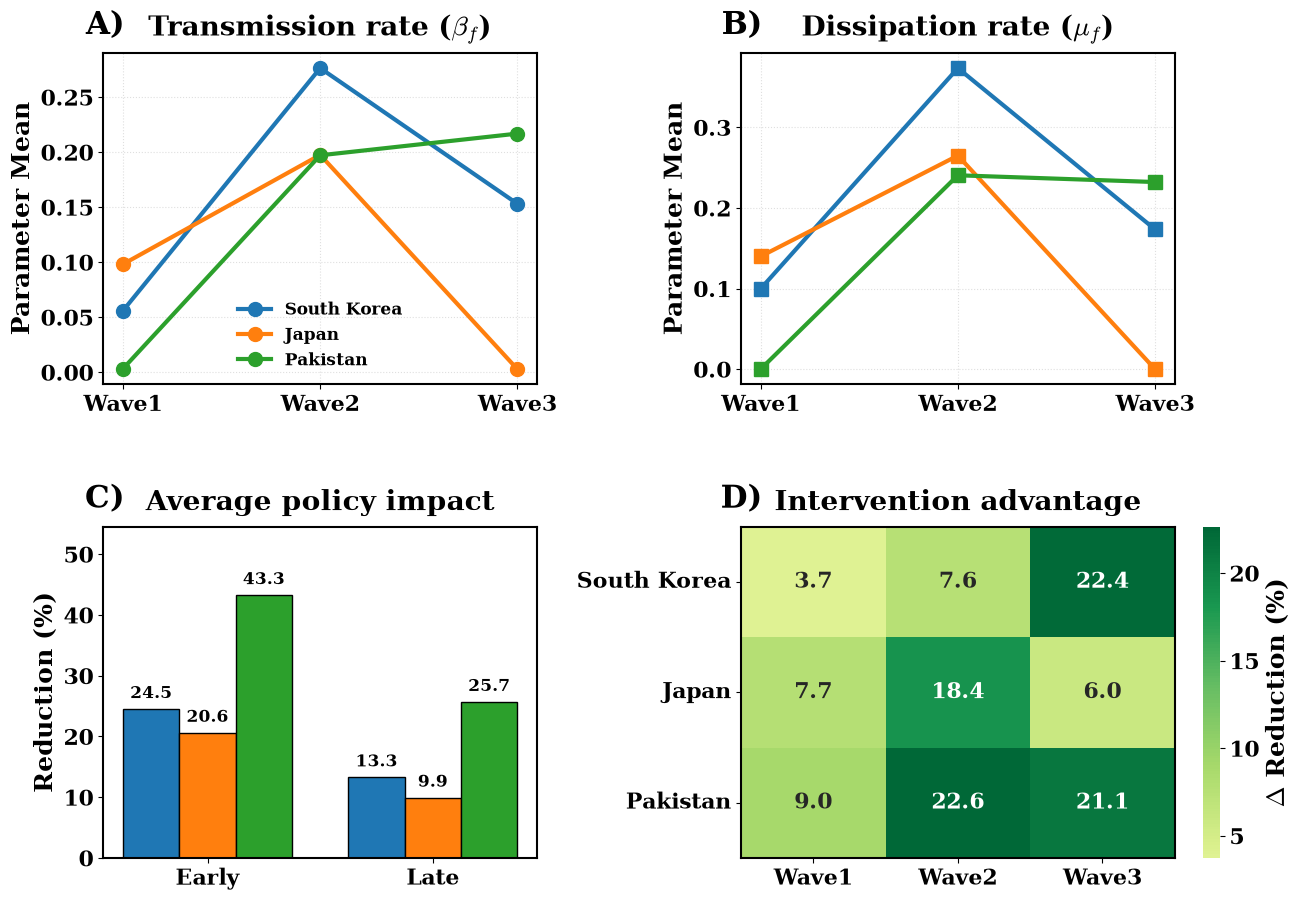

In [10]:


# --- 1. Define the Data Loading Function ---
def load_all_metrics():
    metrics = {}
    for country, directory in COUNTRIES:
        # Load Policy Data
        csv_p = directory / "enkf_policy_impact.csv"
        with csv_p.open(newline="", encoding="utf-8") as h:
            raw_rows = {row["Scenario"].strip().lower(): row for row in csv.DictReader(h)}
            policy = PolicyData(
                averages=np.array([float(raw_rows[s.strip().lower()]["AverageReduction"]) for s in SCENARIO_ORDER]),
                per_wave=np.array([[float(raw_rows[s.strip().lower()][w]) for w in WAVE_COLUMNS] for s in SCENARIO_ORDER])
            )
        
        # Load Parameter Data
        csv_param = directory / "enkpf_parameter_summary.csv"
        with csv_param.open(newline="", encoding="utf-8") as h:
            p_rows = sorted(list(csv.DictReader(h)), key=lambda x: int(x["Wave"]))
            params = ParameterData(
                beta_f=np.array([float(r["beta_f_mean"]) for r in p_rows]),
                mu_f=np.array([float(r["mu_f_mean"]) for r in p_rows])
            )
        metrics[country] = {"policy": policy, "parameters": params}
    return metrics

# --- 2. Define the Plotting Function (Uppercase & Fixed Heatmap) ---
def plot_manuscript_graph(metrics):
    palette = ["#1f77b4", "#ff7f0e", "#2ca02c"] 
    # constrained_layout ensures all 4 boxes stay the same size
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
    # ADDED: Increase wspace and hspace within the constrained layout engine
    # w_pad/h_pad are the space from the edge, wspace/hspace is space between subplots
    fig.set_constrained_layout_pads(  # type: ignore[attr-defined]
    w_pad=0.1,
    h_pad=0.1,
    hspace=0.15,
    wspace=0.01,
    )

    (ax_a, ax_b), (ax_c, ax_d) = axes
    
    country_names = list(metrics.keys())
    wave_pos = [1, 2, 3]

    # Panel A: Transmission
    for i, country in enumerate(country_names):
        p = metrics[country]["parameters"]
        ax_a.plot(wave_pos, p.beta_f, 'o-', lw=3, ms=10, label=country, color=palette[i])
    ax_a.legend(loc='best', frameon=False, fontsize=12) 

    # Panel B: Dissipation
    for i, country in enumerate(country_names):
        p = metrics[country]["parameters"]
        ax_b.plot(wave_pos, p.mu_f, 's-', lw=3, ms=10, color=palette[i])

    # Panel C: Grouped Bar (Policy Impact)
    x_bar = np.arange(len(SCENARIO_ORDER))
    width = 0.25
    for i, country in enumerate(country_names):
        vals = metrics[country]["policy"].averages
        bars = ax_c.bar(x_bar + (i-1)*width, vals, width, color=palette[i], edgecolor='black')
        for bar in bars:
            ax_c.annotate(f'{bar.get_height():.1f}', 
                          xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                          xytext=(0, 5), textcoords="offset points", 
                          ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Panel D: Heatmap (Ensured same size as others)
    diff = np.vstack([metrics[c]["policy"].per_wave[0] - metrics[c]["policy"].per_wave[1] for c in country_names])
    sns.heatmap(diff, ax=ax_d, annot=True, fmt=".1f", cmap="RdYlGn", center=0, 
                xticklabels=WAVE_LABELS, yticklabels=country_names,
                square=False, # FIXED: Allow heatmap to fill the rectangular axis
                annot_kws={"size": 16, "weight": "bold"}, 
                cbar_kws={'label': r'$\Delta$ Reduction (%)', 'pad': 0.02})
    ax_d.set_yticklabels(country_names, rotation=0, fontweight='bold')

    # --- Manuscript Styling with UPPERCASE Labels ---
    titles = [r"Transmission rate ($\beta_f$)", r"Dissipation rate ($\mu_f$)", 
              "Average policy impact", "Intervention advantage"]
    panel_tags = ['A)', 'B)', 'C)', 'D)']

    for i, ax in enumerate(axes.flat):
        ax.set_title(titles[i], pad=12, fontsize=20, fontweight='bold')
        # Add Uppercase tags A), B), C), D)
        ax.text(0.05, 1.13, panel_tags[i], transform=ax.transAxes, 
                fontsize=22, fontweight='bold', va='top', ha='right')
        
        for spine in ax.spines.values(): spine.set_visible(True) 
        
        if i < 2: # Top row
            ax.set_xticks(wave_pos); 
            ax.set_xticklabels(WAVE_LABELS)
            ax.set_ylabel("Parameter Mean", fontweight='bold')
            ax.grid(True, linestyle=':', alpha=0.4)
        elif i == 2: # Bottom left
            ax.set_xticks(x_bar); 
            ax.set_xticklabels(["Early", "Late"], fontweight='bold')
            ax.set_ylabel("Reduction (%)", fontweight='bold')
            ax.set_ylim(0, max(ax_c.get_ylim()) * 1.2) 

    # Save and Show
    fig.savefig(OUTPUT_DIR / "Figure2_Manuscript.png", dpi=600, bbox_inches='tight')
    plt.show()

# --- 3. Execution Block ---
try:
    # This now works because the function is defined above in the same cell
    data_metrics = load_all_metrics()
    plot_manuscript_graph(data_metrics)
except Exception as e:
    print(f"Error: {e}")

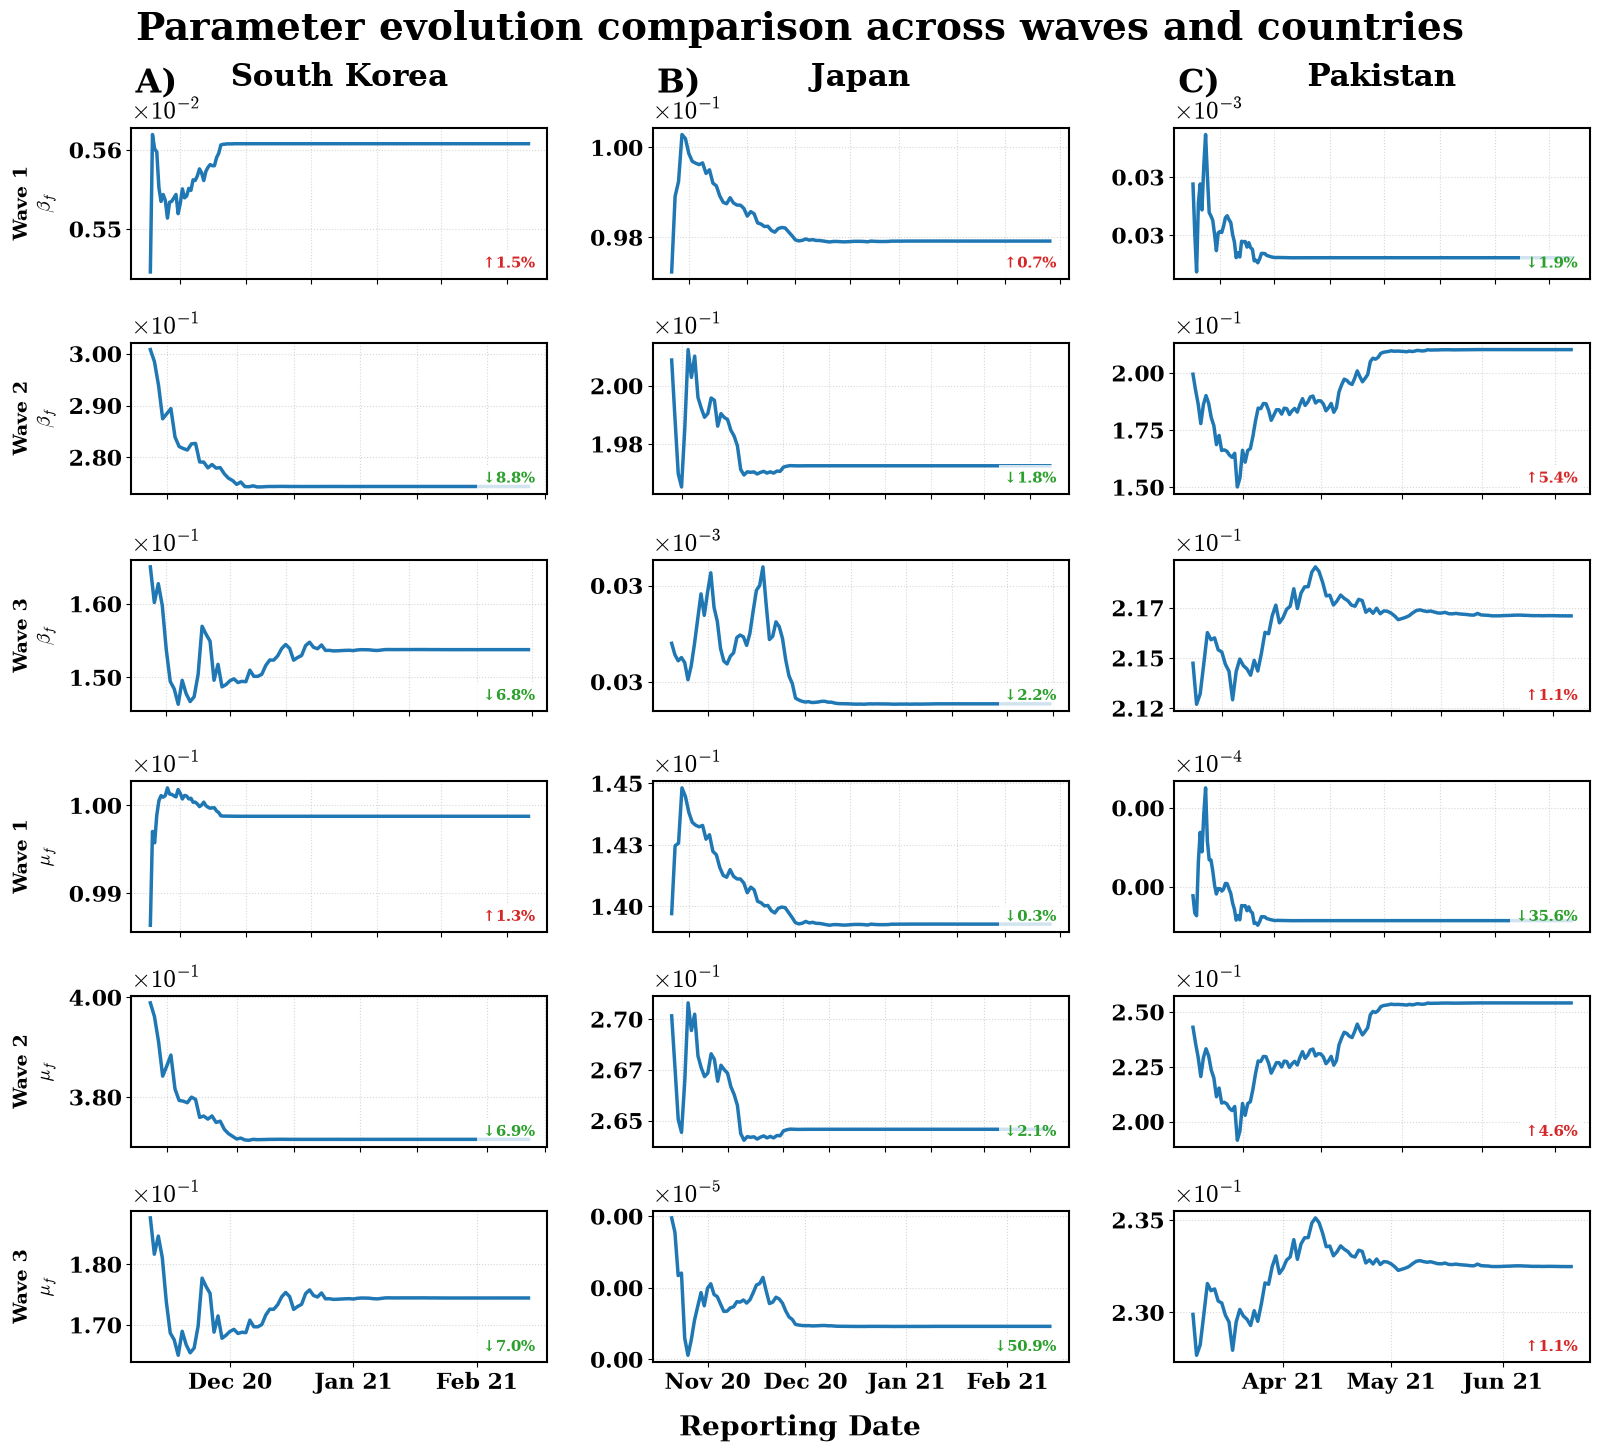

In [11]:
def create_columnar_parameters_figure():
    # Mapping to ensure correct folder and config lookup
    countries = ['South Korea', 'Japan', 'Pakistan']
    folder_map = {'South Korea': 'Korea', 'Japan': 'Japan', 'Pakistan': 'Pakistan'}
    
    mat_paths = {
        c: DATA_DIR / folder_map[c] / f'{folder_map[c]}Data.mat' for c in countries
    }
    
    # 6 rows x 3 columns
    fig, axes = plt.subplots(6, 3, figsize=(16, 14), constrained_layout=True)
    
    # Keeping your perfect padding settings
    fig.set_constrained_layout_pads(  # type: ignore[attr-defined]
    w_pad=0.1,
    h_pad=0.1,
    hspace=0.12,
    wspace=0.08,
)
   # fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.1, hspace=0.12, wspace=0.08)

    fig.suptitle('Parameter evolution comparison across waves and countries', 
                 fontsize=28, fontweight='bold', y=1.03)

    fig.supxlabel('Reporting Date', fontsize=20, fontweight='bold')

    parameters = [(r'$\beta_f$', 6), (r'$\mu_f$', 7)]
    panel_tags = ['A)', 'B)', 'C)'] 

    for col, country in enumerate(countries):
        try:
            # 1. Load Data
            mat_data = loadmat(mat_paths[country])
            
            # 2. Load Excel Dates (Using the logic from your "Correct" file)
            config = EXCEL_CONFIG[country]
            df = pd.read_excel(config['path'])
            date_col = df[config['date_column']]
            
        except Exception as e:
            print(f"Warning: Error loading data for {country}: {e}")
            continue

        for p_idx_in_list, (p_name, p_mat_idx) in enumerate(parameters):
            for wave_idx in range(3):
                row_idx = (p_idx_in_list * 3) + wave_idx
                ax = axes[row_idx, col]
                
                key = f'x_hatenkfP{wave_idx+1}'
                if key in mat_data:
                    data = mat_data[key][p_mat_idx].flatten()
                    
                    # --- FIX: GET CORRECT DATES FROM EXCEL ---
                    # Identify the range for this specific wave
                    wave_range = config['wave_ranges'][wave_idx]
                    start_idx = wave_range[0] - 1 # Convert to 0-based
                    
                    # Slice the dates to match the length of the parameter data
                    t_vec = pd.to_datetime(date_col.iloc[start_idx : start_idx + len(data)])
                    
                    # Plotting
                    ax.plot(t_vec, data, lw=2.5, color='#1f77b4') 
                    ax.grid(True, linestyle=':', alpha=0.5)
                    
                    # --- Scientific Notation (Keeping your perfect settings) ---
                    max_val = np.nanmax(np.abs(data))
                    exp = math.floor(math.log10(max_val)) if max_val > 0 else 0
                    
                    formatter = FuncFormatter(lambda x, pos: f'{(x / 10**exp):.2f}')
                    ax.yaxis.set_major_formatter(formatter)

                    # Multiplier ABOVE the graph box (at your 1.02 and 18pt setting)
                    ax.text(0.0, 1.02, f'$\\times 10^{{{exp}}}$', transform=ax.transAxes, 
                            fontsize=18, fontweight='bold', va='bottom', ha='left')
                    
                    # --- Percent Change Annotation ---
                    pc = ((data[-1] - data[0]) / data[0]) * 100
                    txt, col_txt = (f'↑{pc:.1f}%', '#d62728') if pc >= 0 else (f'↓{abs(pc):.1f}%', '#2ca02c')
                    ax.text(0.97, 0.05, txt, transform=ax.transAxes, fontsize=11, 
                            fontweight='bold', color=col_txt, ha='right', va='bottom',
                            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

                    # --- X-Axis Formatting (Now using formatted dates) ---
                    if row_idx < 5:
                        ax.set_xticklabels([])
                    else:
                        # Only the bottom row shows dates
                        ax.xaxis.set_major_locator(MonthLocator(interval=1))
                        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
                        plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize=16, fontweight='bold')
                
                # --- Column Headers ---
                if row_idx == 0:
                    # Center the country subtitle and put panel tag in the top-left corner (consistent with other figures)
                    ax.set_title(f"{country}", loc='center', fontsize=22, pad=30, fontweight='bold')
                    # Place tag above the multiplier/axis offset to avoid overlap with the exponent annotation
                    ax.text(0.01, 1.40, panel_tags[col], transform=ax.transAxes, fontsize=24, fontweight='bold', va='top', ha='left')
                    
                # --- Row Labels ---
                if col == 0:
                    label_str = f"Wave {wave_idx+1}\n{p_name}"
                    ax.set_ylabel(label_str, fontsize=14, fontweight='bold', 
                                 rotation=90, labelpad=25, va='center')

    save_path = OUTPUT_DIR / "Figure3_Parameters_Dates_Fixed.png"
    fig.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()

create_columnar_parameters_figure()

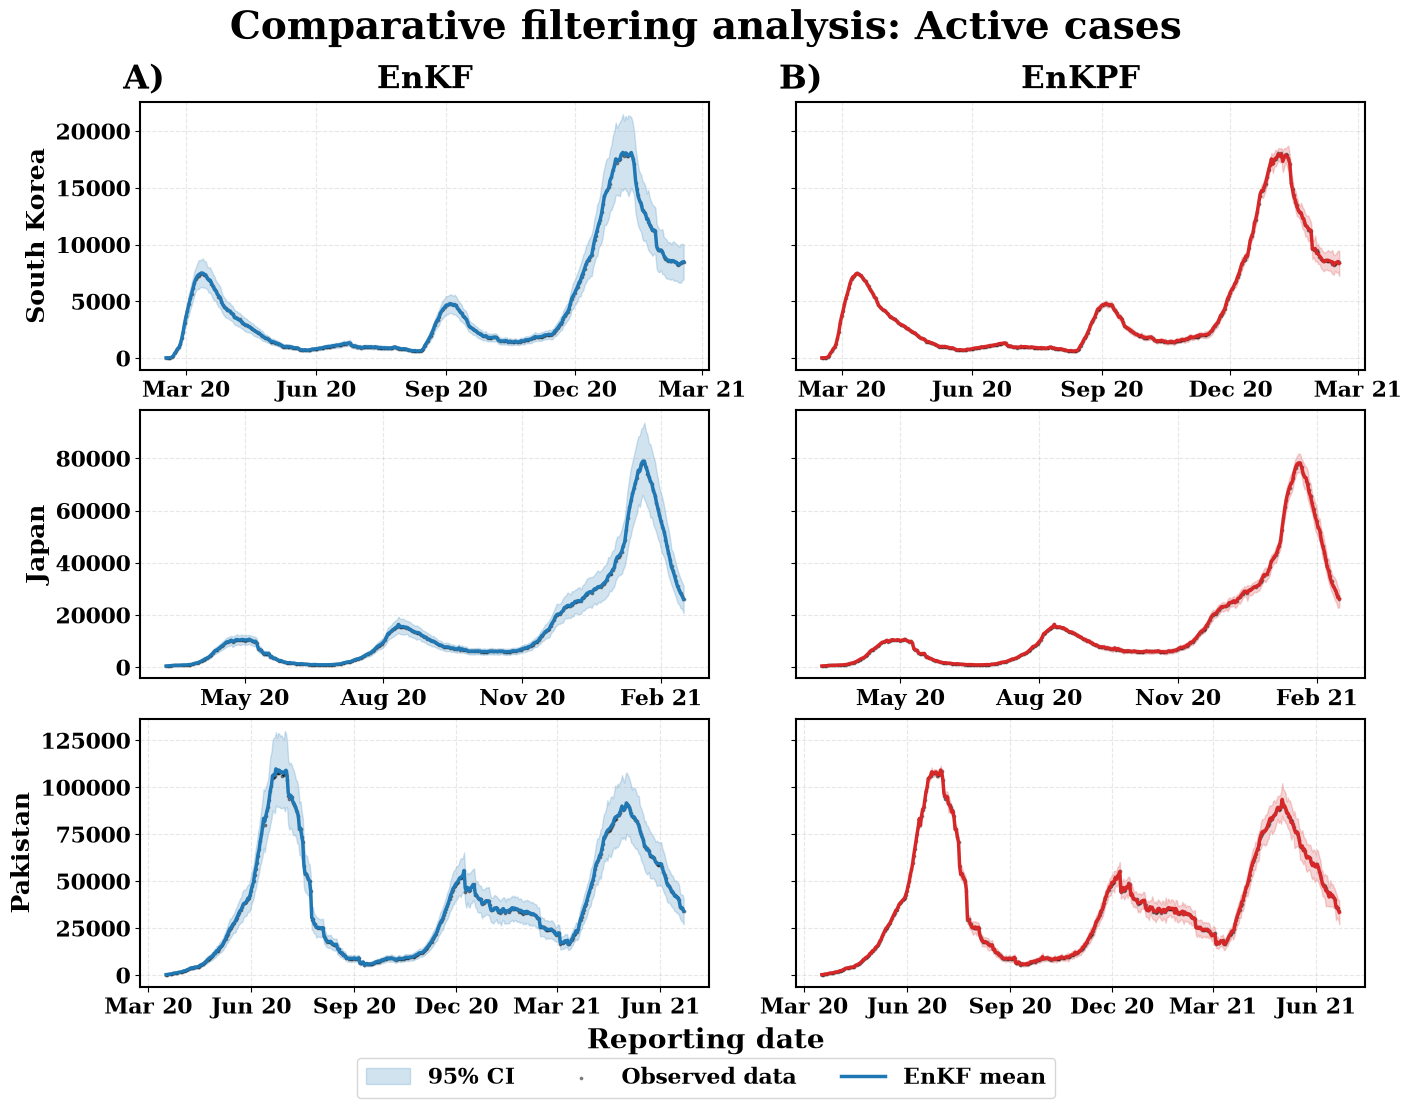

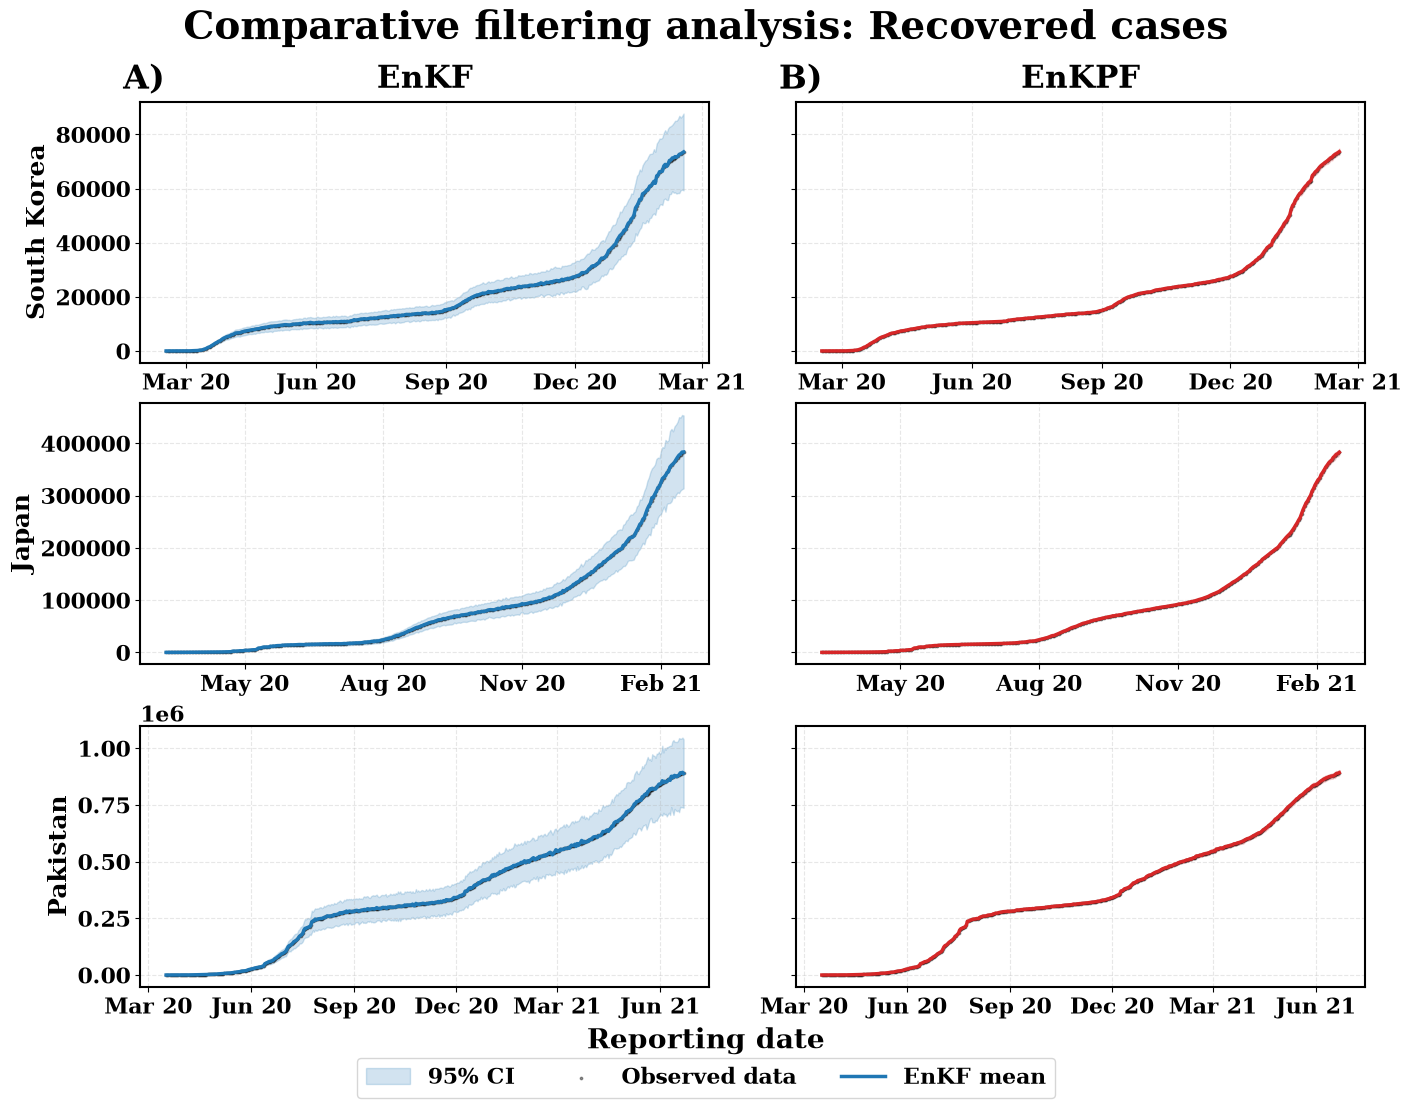

In [12]:


def create_combined_cases_figure():
    from matplotlib.colors import to_rgba
    
    countries = ['Korea', 'Japan', 'Pakistan']
    country_names = ['South Korea', 'Japan', 'Pakistan']
    data = {}
    
    # --- Data Loading (Kept consistent with your structure) ---
    for country, name in zip(countries, country_names):
        mat_path = DATA_DIR / country / f'{country}Data.mat'
        mat_data = loadmat(mat_path)
        config = EXCEL_CONFIG[name]
        df = pd.read_excel(config['path'])
        date_col = df[config['date_column']]
        start_idx = config['wave_ranges'][0][0] - 1
        data_length = mat_data['x_hat_combined'].shape[1]
        dates = pd.to_datetime(date_col.iloc[start_idx : start_idx + data_length])
        
        data[name] = {
            'P': mat_data['P_combined'],
            'PenkfP': mat_data['PenkfP_combined'],
            'z': mat_data['z_combined'],
            'x_hat': mat_data['x_hat_combined'],
            'x_hatenkfP': mat_data['x_hatenkfP_combined'],
            'Date': dates
        }

    def plot_cases_comparison(compartment_idx, compartment_name, filename):
        # Create figure: sharey='row' ensures EnKF and EnKPF use the same scale for a country
        fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=False, sharey='row', constrained_layout=True)
        
        methods = [
            ('EnKF', 'x_hat', 'P', '#1f77b4'),     # Professional Blue
            ('EnKPF', 'x_hatenkfP', 'PenkfP', '#d62728') # Professional Red
        ]

        for row_idx, country in enumerate(country_names):
            for col, (method_name, x_key, p_key, color) in enumerate(methods):
                ax = axes[row_idx, col]
                d = data[country]
                
                # Confidence Interval Calculation
                n = len(d['Date'])
                # Vectorized sqrt for speed
                std_val = np.sqrt(d[p_key][compartment_idx-1, compartment_idx-1, :])
                ci_upper = d[x_key][compartment_idx-1, :] + 1.96 * std_val
                ci_lower = d[x_key][compartment_idx-1, :] - 1.96 * std_val
                
                # 1. Plot 95% CI
                ax.fill_between(d['Date'], ci_upper, ci_lower, color=color, alpha=0.2, label='95% CI')
                
                # 2. Plot Observed Data (Scatter dots are better for "Data")
                ax.scatter(d['Date'], d['z'][compartment_idx-4, :], s=3, color='black', alpha=0.4, label='Observed data', zorder=2)
                
                # 3. Plot Mean Prediction
                ax.plot(d['Date'], d[x_key][compartment_idx-1, :], color=color, lw=2.5, label=f'{method_name} mean', zorder=3)
                
                # --- Formatting ---
                ax.grid(True, linestyle='--', alpha=0.3)
                
                # Column Titles (Method) - Only on top row; place panel letters in top-left corner
                if row_idx == 0:
                    panel_label = 'A)' if col == 0 else 'B)'
                    ax.set_title(f"{method_name}", fontsize=22, pad=10, fontweight='bold')
                    ax.text(-0.03, 1.05, panel_label, transform=ax.transAxes, fontsize=24, fontweight='bold')
                
                # Row Titles (Country) - Only on right side or left side
                if col == 0:
                    ax.set_ylabel(f"{country}", fontsize=18, fontweight='bold')

                # X-Axis formatting
                ax.xaxis.set_major_locator(MonthLocator(interval=3))
                ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))

        # Add overall Common labels
        fig.suptitle(f'Comparative filtering analysis: {compartment_name} cases', fontsize=28, fontweight='bold', y=1.05)
        fig.supxlabel('Reporting date', fontsize=20, fontweight='bold')
        
        # Unified Legend - positioned at the bottom
        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05), fontsize=16, frameon=True)

        fig.savefig(OUTPUT_DIR / filename, dpi=600, bbox_inches='tight')
        plt.show()

    # Generate the two manuscript figures
    plot_cases_comparison(4, "Active", "Figure4_Active_Professional.png")
    plot_cases_comparison(5, "Recovered", "Figure5_Recovered_Professional.png")

# Run the function
create_combined_cases_figure()

## Combined RMSE Figure (3x2 panels) — Data-based

Display the RMSE comparison figure generated by the MATLAB script (`combined_rmse_3x2_data.m`).

If the figure PNG is not present, run the MATLAB script to produce the image in `../Figures`.

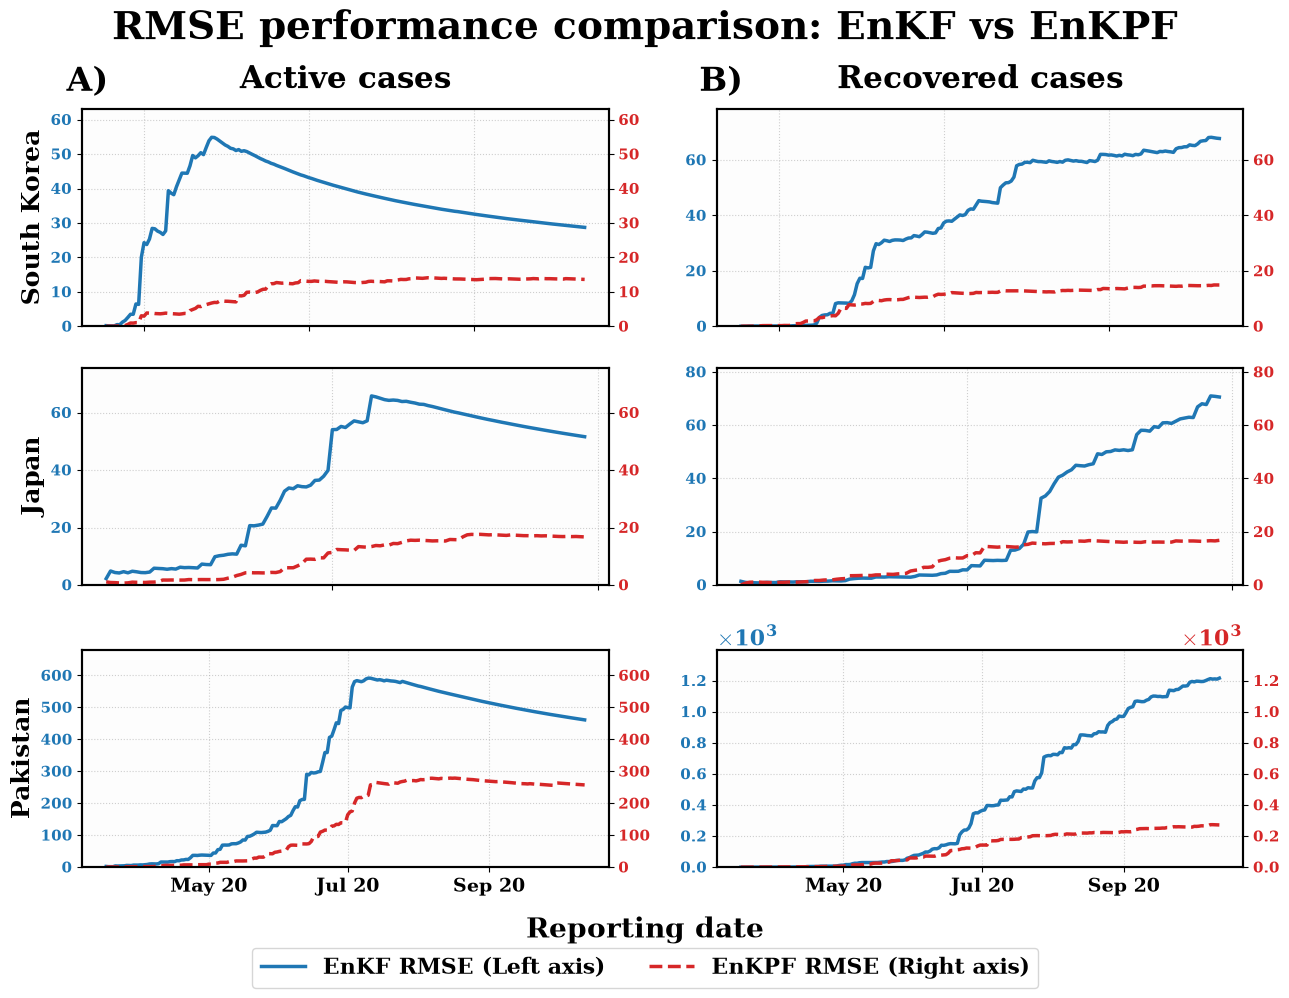

In [13]:


def create_combined_rmse_figure():
    countries = ['South Korea', 'Japan', 'Pakistan']
    folder_map = {'South Korea': 'Korea', 'Japan': 'Japan', 'Pakistan': 'Pakistan'}
    
    # Use constrained_layout=True for consistent box sizing
    fig, axes = plt.subplots(3, 2, figsize=(13, 9), constrained_layout=True)
    
    # Adjust padding to prevent overlap with dual y-axis labels
    
    fig.set_constrained_layout_pads(  # type: ignore[attr-defined]
    w_pad=0.15,
    h_pad=0.1,
    hspace=0.1,
    wspace=0.01,
    )
    #fig.set_constrained_layout_pads(w_pad=0.15, h_pad=0.1, hspace=0.1, wspace=0.01)
    
    fig.suptitle('RMSE performance comparison: EnKF vs EnKPF', 
                 fontsize=28, fontweight='bold', y=1.05)

    fig.supxlabel('Reporting date', fontsize=20, fontweight='bold')

    # Color definitions to match previous figures
    color_enkf = '#1f77b4'  # Professional Blue
    color_enkpf = '#d62728' # Professional Red

    for row_idx, country in enumerate(countries):
        folder = folder_map[country]
        path = DATA_DIR / folder / f'{folder}Data.mat'
        
        # --- Data Loading ---
        config = EXCEL_CONFIG[country]
        df = pd.read_excel(config['path'])
        start_idx = config['wave_ranges'][0][0] - 1
        
        try:
            mat = loadmat(path)
            data_len = len(mat['RMS_Q1'].flatten())
            dates = pd.to_datetime(df[config['date_column']].iloc[start_idx : start_idx + data_len])
        except Exception as e:
            print(f"Error loading {country}: {e}")
            continue

        plot_configs = [
            {'enkf': 'RMS_Q1', 'enkpf': 'RMS_Q_enkfP1', 'title': 'Active cases'},
            {'enkf': 'RMS_R1', 'enkpf': 'RMS_R_enkfP1', 'title': 'Recovered cases'}
        ]

        for col, config_item in enumerate(plot_configs):
            ax_left = axes[row_idx, col]
            ax_right = ax_left.twinx()  
            
            rmse_enkf = mat[config_item['enkf']].flatten()
            rmse_enkpf = mat[config_item['enkpf']].flatten()

            # --- Plotting ---
            ax_left.plot(dates, rmse_enkf, color=color_enkf, lw=2.5, label='EnKF')
            ax_right.plot(dates, rmse_enkpf, color=color_enkpf, lw=2.5, label='EnKPF', linestyle='--')
            
            # --- Styling ---
            ax_left.grid(True, linestyle=':', alpha=0.6)
            ax_left.set_facecolor('#fdfdfd')

            # --- Y-Axis Formatting ---
            ax_left.tick_params(axis='y', labelcolor=color_enkf, labelsize=11)
            ax_right.tick_params(axis='y', labelcolor=color_enkpf, labelsize=11)

            # Column 0: Show Country Name
            if col == 0:
                ax_left.set_ylabel(f"{country}", color='black', fontsize=18, fontweight='bold')
            
            # Sync Y-limits for fair comparison between scales if needed
            top_limit = max(np.nanmax(rmse_enkf), np.nanmax(rmse_enkpf)) * 1.15
            ax_left.set_ylim(0, top_limit)
            ax_right.set_ylim(0, top_limit)

            # Scientific notation for both axes
            for ax_target in [ax_left, ax_right]:
                formatter = ScalarFormatter(useMathText=True)
                formatter.set_scientific(True)
                formatter.set_powerlimits((-2, 3))
                ax_target.yaxis.set_major_formatter(formatter)

            # --- Date Formatting ---
            ax_left.xaxis.set_major_locator(MonthLocator(interval=2))
            ax_left.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
            
            # Hide x-labels for top and middle rows
            if row_idx < 2:
                ax_left.set_xticklabels([])
            else:
                plt.setp(ax_left.xaxis.get_majorticklabels(), rotation=0, fontsize=14)

            # --- Column Headers and Panel Tags (Only top row) ---
            if row_idx == 0:
                panel_label = 'A)' if col == 0 else 'B)'
                ax_left.set_title(config_item['title'], fontsize=22, pad=15, fontweight='bold')
                
                # Consistent Uppercase Alignment with previous figures
                ax_left.text(0.05, 1.2, panel_label, transform=ax_left.transAxes, 
                             fontsize=24, fontweight='bold', va='top', ha='right')

    # --- Combined Legend ---
    legend_elements = [
        Line2D([0], [0], color=color_enkf, lw=2.5, label='EnKF RMSE (Left axis)'),
        Line2D([0], [0], color=color_enkpf, lw=2.5, linestyle='--', label='EnKPF RMSE (Right axis)')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2, 
                bbox_to_anchor=(0.5, -0.05), fontsize=16, frameon=True, shadow=False)

    # Save high-quality version
    save_path = OUTPUT_DIR / "Figure_RMSE_Manuscript_Final.png"
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()

create_combined_rmse_figure()

Manuscript figure saved to: c:\Users\ABBASWASIM\OneDrive - pnu.ac.kr\2025\matlab\SAJIDA papers\paper work poisson_enkf_enkpf\Final\writing\ipynb_bundle\Figures2\Figure4_Behavioral_Parameters.png


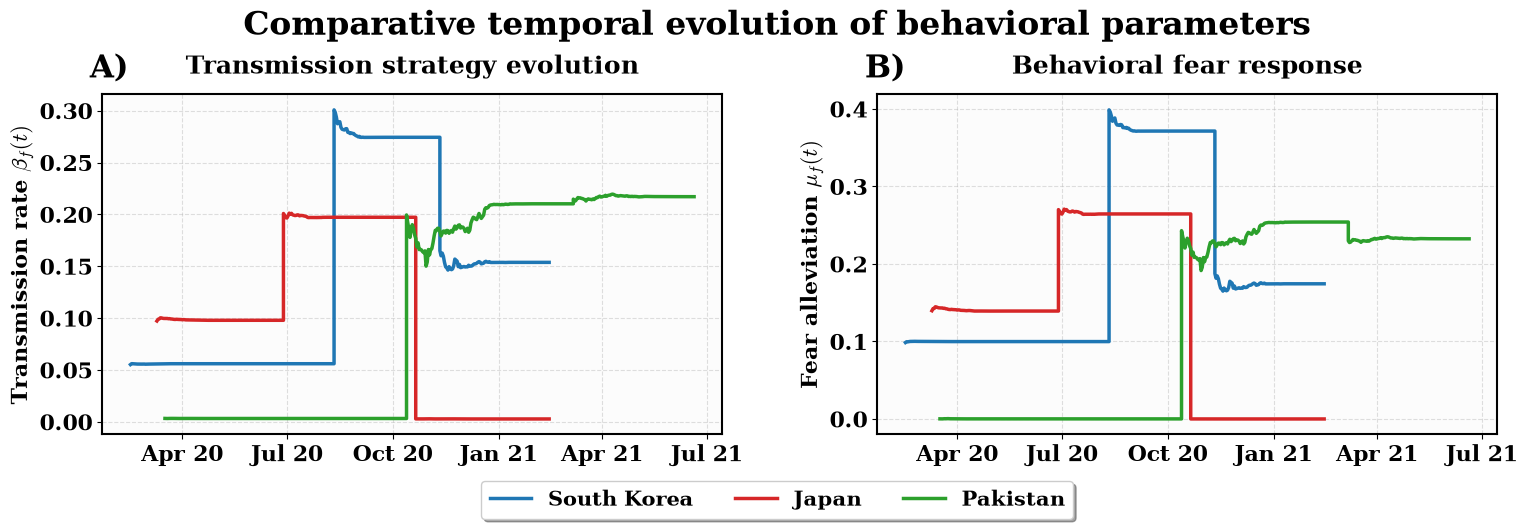

In [14]:


def create_fig4_combined_3countries():
    countries = ['South Korea', 'Japan', 'Pakistan']
    folder_map = {'South Korea': 'Korea', 'Japan': 'Japan', 'Pakistan': 'Pakistan'}
    data = {}
    colors = {'South Korea': '#1f77b4', 'Japan': '#d62728', 'Pakistan': '#2ca02c'}

    for country in countries:
        folder = folder_map[country]
        path = DATA_DIR / folder / f'{folder}Data.mat'
        
        # 1. Load Ground Truth Dates from Excel (Same logic as RMSE cell)
        config = EXCEL_CONFIG[country]
        df = pd.read_excel(config['path'])
        
        try:
            mat = loadmat(path)
            all_beta = []
            all_mu = []
            all_dates = []
            
            # 2. Iterate through Waves 1, 2, and 3
            for i, (start_idx, end_idx) in enumerate(config['wave_ranges']):
                wave_num = i + 1
                x_key = f'x_hatenkfP{wave_num}'
                
                if x_key in mat:
                    x = np.asarray(mat[x_key])
                    if x.ndim == 1: x = x.reshape(1, -1)
                    
                    # Extract Beta (Row 6) and Mu (Row 7)
                    beta_wave = x[6, :].flatten()
                    mu_wave = x[7, :].flatten()
                    
                    # Slice exact dates for this wave from Excel
                    # MATLAB 1-based start_idx converted to 0-based
                    d_wave = pd.to_datetime(df[config['date_column']].iloc[start_idx-1 : start_idx-1 + len(beta_wave)])
                    
                    all_beta.append(beta_wave)
                    all_mu.append(mu_wave)
                    all_dates.append(d_wave)

            # Combine waves into a single timeline per country
            data[country] = {
                'dates': pd.concat(all_dates), 
                'beta': np.concatenate(all_beta), 
                'mu': np.concatenate(all_mu)
            }
        except Exception as e:
            print(f"Error processing {country}: {e}")
            continue

    # 3. Setup Figure (1 row, 2 columns)
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    fig.subplots_adjust(bottom=0.2, top=0.88, wspace=0.25)
    fig.patch.set_facecolor('white')

    plot_settings = [
        {'key': 'beta', 'ylabel': r"Transmission rate $\beta_f(t)$", 'title': 'Transmission strategy evolution', 'tag': 'A)'},
        {'key': 'mu', 'ylabel': r"Fear alleviation $\mu_f(t)$", 'title': 'Behavioral fear response', 'tag': 'B)'}
    ]

    for col, settings in enumerate(plot_settings):
        ax = axes[col]
        for country in countries:
            if country in data:
                d = data[country]
                ax.plot(d['dates'], d[settings['key']], color=colors[country], lw=2.5, label=country)

        # Formatting
        ax.set_title(settings['title'], fontsize=18, fontweight='bold', pad=15)
        ax.set_ylabel(settings['ylabel'], fontsize=16, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.set_facecolor('#fcfcfc')
        
        # Subplot lettering
        ax.text(-0.02, 1.05, settings['tag'], transform=ax.transAxes, fontsize=22, fontweight='bold')

        # Date Axis Ticks
        ax.xaxis.set_major_locator(MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
        plt.setp(ax.get_xticklabels(), rotation=0)

    # 4. Global Figure Elements
    fig.suptitle('Comparative temporal evolution of behavioral parameters', 
                 fontsize=24, fontweight='bold', y=1.05)

    # Unified Legend at Bottom
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.01),
               fontsize=15, frameon=True, shadow=True)

    # Save
    out_path = OUTPUT_DIR / 'Figure4_Behavioral_Parameters.png'
    fig.savefig(out_path, dpi=600, bbox_inches='tight')
    print(f'Manuscript figure saved to: {out_path}')
    plt.show()

create_fig4_combined_3countries()

In [15]:
# Quick fix: ensure PARAM_NAMES contains valid mathtext strings (fix any accidental double-escaping)
PARAM_NAMES = [r'$\beta$', r'$\beta_f$', r'$\mu_f$', r'$I(0)$']


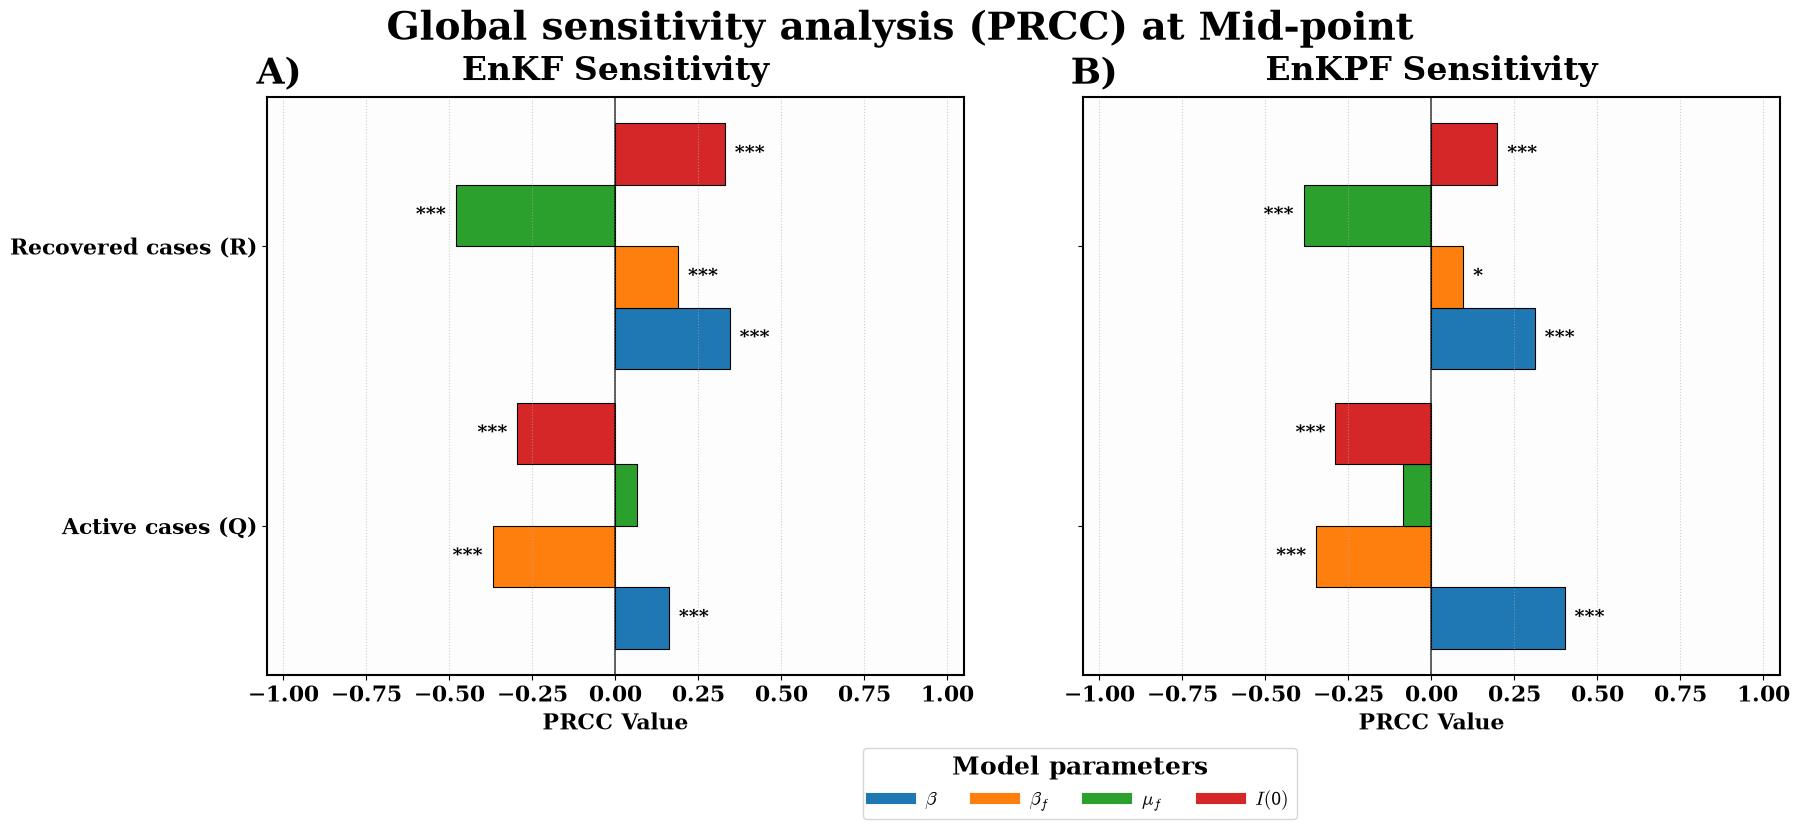

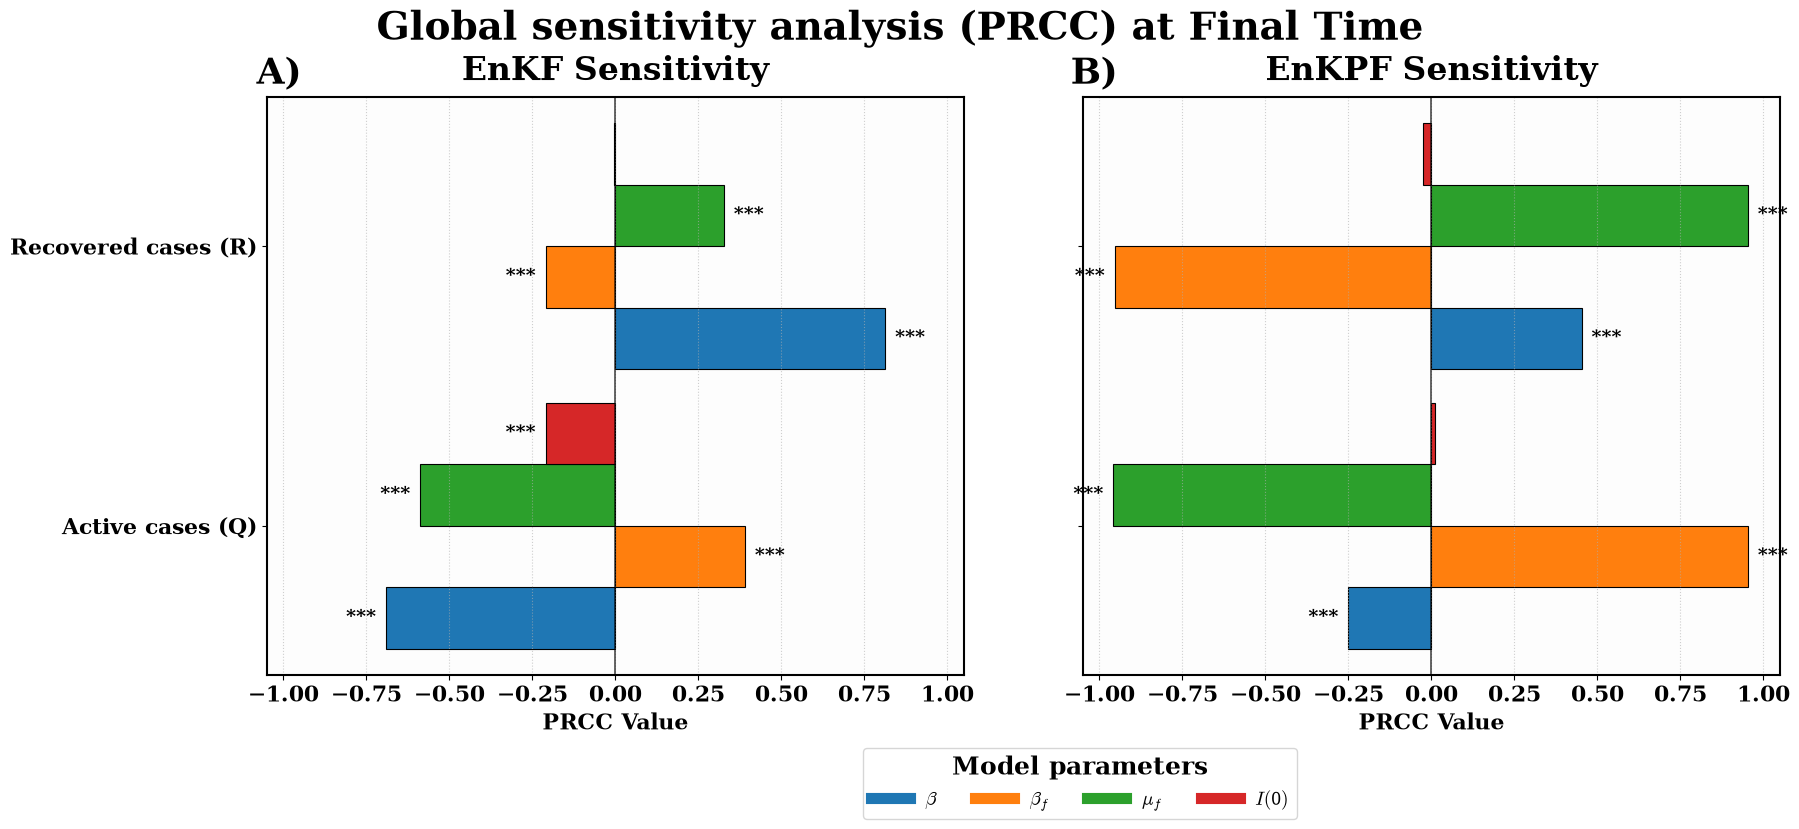

In [16]:


# --- Configuration & Styling ---
N_SAMPLES = 500
N_PARAMS = 4 
PARAM_NAMES = [r'$\beta$', r'$\beta_f$', r'$\mu_f$', r'$I(0)$']
OUTPUT_NAMES = ['Active cases (Q)', 'Recovered cases (R)']
PARAM_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Distinct professional colors
np.random.seed(12345)
from typing import Any
# --- Helper Functions ---

def _sym_pd(matcov):
    """Ensure matrix is symmetric positive-definite for sampling."""
    C = (matcov + matcov.T) / 2
    eps = 1e-8 * np.eye(C.shape[0])
    return C + eps

def modeleq_py(t, x, params):
    """9-state ODE model translated from MATLAB."""
    Lambda, mu, rbeta, gamma, alpha, mmu, delta = (5.9/1000)*(1/365), (5.7/1000)*(1/365), 0.02, 1/4, 1/14, 0.0221, 1/1000
    N, S, I, Q, R = x[0], x[1], x[2], x[3], x[4]
    Sf = N - (S + I + Q + R)
    beta, betaf, muf = params[0], params[1], params[2]
    
    dx = np.zeros(9)
    dx[0] = Lambda*N - mu*N - mmu*Q # N
    dx[1] = Lambda*N - (beta*S*I / N) - betaf*S*(1 - np.exp(-delta*Q)) + ((muf*Sf*(S+R))/N) - mu*S # S
    dx[2] = (beta*S*I / N) + (rbeta*beta*Sf*I / N) - (gamma + mu)*I # I
    dx[3] = gamma*I - (mu + alpha + mmu)*Q # Q
    dx[4] = alpha*Q - mu*R # R
    return dx

def calculate_prcc(X, Y):
    """Computes Partial Rank Correlation Coefficients and p-values.

    Returns:
        prcc: shape (n_params, n_outputs) of PRCC values
        pvals: shape (n_params, n_outputs) of associated p-values from Pearson r test on residuals
    """
    n_samples, n_params = X.shape
    n_outputs = Y.shape[1]
    X_rank = np.array([rankdata(X[:, i]) for i in range(n_params)]).T
    Y_rank = np.array([rankdata(Y[:, j]) for j in range(n_outputs)]).T
    
    prcc = np.zeros((n_params, n_outputs))
    pvals = np.ones((n_params, n_outputs))
    for i in range(n_params):
        X_ex = np.delete(X_rank, i, axis=1)
        Z = np.column_stack([np.ones(n_samples), X_ex])
        # Regression to find residuals
        b1 = np.linalg.lstsq(Z, X_rank[:, i], rcond=None)[0]
        res1 = X_rank[:, i] - Z.dot(b1)
        for j in range(n_outputs):
            b2 = np.linalg.lstsq(Z, Y_rank[:, j], rcond=None)[0]
            res2 = Y_rank[:, j] - Z.dot(b2)
            res: Any = pearsonr(res1, res2)
            prcc[i, j] = float(res[0])
            pvals[i, j] = float(res[1])
    return prcc, pvals

# --- Main Execution ---

# Load data
mat_path = DATA_DIR / 'Korea' / 'KoreaData.mat'
mat = loadmat(mat_path)

x_hat = mat['x_hat_combined']
x_hatenkfP = mat['x_hatenkfP_combined']
P_combined = mat['P_combined']
PenkfP_combined = mat['PenkfP_combined']
if x_hat is None:
    print('Required variables missing in MAT file.')
else:
    n_state = x_hat.shape[0]
    param_indices = np.arange(n_state - N_PARAMS, n_state)
    n_time = x_hat.shape[1]
    time_points = [n_time // 2, n_time - 1] # Mid-point and Final-point

    for t_idx in time_points:
        # Sampling
        mu_enkf = x_hat[param_indices, t_idx]
        mu_enkfp = x_hatenkfP[param_indices, t_idx]
        cov_enkf = _sym_pd(P_combined[np.ix_(param_indices, param_indices, [t_idx])][:, :, 0])
        cov_enkfp = _sym_pd(PenkfP_combined[np.ix_(param_indices, param_indices, [t_idx])][:, :, 0])
        
        samples_enkf = np.clip(np.random.multivariate_normal(mu_enkf, cov_enkf, size=N_SAMPLES), 0, None)
        samples_enkfp = np.clip(np.random.multivariate_normal(mu_enkfp, cov_enkfp, size=N_SAMPLES), 0, None)

        # Integration
        x0_base = x_hat[0:9, 0].astype(float)
        t_eval = [0, t_idx] if t_idx > 0 else [0, 1]
        outputs_enkf, outputs_enkfp = np.zeros((N_SAMPLES, 2)), np.zeros((N_SAMPLES, 2))

        for i in range(N_SAMPLES):
            for out_arr, samp_arr in [(outputs_enkf, samples_enkf), (outputs_enkfp, samples_enkfp)]:
                p_i = samp_arr[i, :]
                x0 = x0_base.copy(); x0[2] = p_i[3] # Update I(0)
                sol = solve_ivp(lambda t, y: modeleq_py(t, y, p_i), (0, t_idx), x0, t_eval=[t_idx])
                if sol.success:
                    out_arr[i, 0] = sol.y[3, -1] # Q
                    out_arr[i, 1] = sol.y[4, -1] # R

        # Calculate PRCC and p-values
        prcc_enkf, p_enkf = calculate_prcc(samples_enkf, outputs_enkf)
        prcc_enkfp, p_enkfp = calculate_prcc(samples_enkfp, outputs_enkfp)

        # --- PLOTTING 1x2 PANEL ---
        # Using constrained_layout for better title/label management
        fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
        
        # Consistent spacing for titles and tags
        fig.set_constrained_layout_pads(  # type: ignore[attr-defined]
            w_pad=0.1,
            h_pad=0.1,
            hspace=0.1,
            wspace=0.1,
        )
       # fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.1, hspace=0.1, wspace=0.1)
        
        methods = [('EnKF Sensitivity', prcc_enkf, p_enkf, 'A)'), ('EnKPF Sensitivity', prcc_enkfp, p_enkfp, 'B)')]

        def _p_to_stars(p):
            if p < 0.001:
                return '***'
            elif p < 0.01:
                return '**'
            elif p < 0.05:
                return '*'
            else:
                return ''

        for col, (title, data, pvals, tag) in enumerate(methods):
            ax = axes[col]
            y_pos = np.arange(len(OUTPUT_NAMES))
            height = 0.22 # Slightly thicker bars for better visibility

            for i in range(N_PARAMS):
                offset = (i - (N_PARAMS - 1) / 2) * height
                ax.barh(y_pos + offset, data[i, :], height=height,
                        color=PARAM_COLORS[i], label=PARAM_NAMES[i],
                        edgecolor='black', linewidth=0.8)

                # Annotate significance stars per output
                for j in range(len(OUTPUT_NAMES)):
                    pval = pvals[i, j]
                    star = _p_to_stars(pval)
                    if star:
                        val = data[i, j]
                        x_off = 0.03 if val >= 0 else -0.03
                        x = val + x_off
                        ha = 'left' if val >= 0 else 'right'
                        ax.text(x, y_pos[j] + offset, star, va='center', ha=ha, fontsize=14, fontweight='bold')

            # Formatting
            ax.set_yticks(y_pos)
            if col == 0:
                ax.set_yticklabels(OUTPUT_NAMES, fontsize=14, fontweight='bold')
            else:
                ax.set_yticklabels([])

            ax.set_xlim([-1.05, 1.05])
            ax.set_xlabel('PRCC Value', fontsize=16, fontweight='bold')

            # --- ALIGNMENT FIX: center subplot title and put tag in corner ---
            ax.set_title(title, fontsize=24, fontweight='bold', pad=12, loc='center')
            ax.text(0.05, 1.07, tag, transform=ax.transAxes, fontsize=26, fontweight='bold', va='top', ha='right')

            ax.axvline(0, color='black', lw=1.2, alpha=0.7)
            ax.grid(axis='x', linestyle=':', alpha=0.6)
            ax.set_facecolor('#fdfdfd')
            ax.tick_params(axis='both', labelsize=16)

        # Figure Level Elements
        time_label = "Mid-point" if t_idx == n_time // 2 else "Final Time"
        # Restore suptitle to sit above subplot titles (consistent with other figures)
        fig.suptitle(f'Global sensitivity analysis (PRCC) at {time_label}', 
                     fontsize=28, fontweight='bold', y=1.05)

        # Legend - Bottom centered
        legend_elements = [Line2D([0], [0], color=PARAM_COLORS[i], lw=8, label=PARAM_NAMES[i]) for i in range(N_PARAMS)]
        fig.legend(handles=legend_elements, loc='lower center', ncol=4, bbox_to_anchor=(0.6, -0.12),
                    fontsize=14, title='Model parameters', title_fontsize=18, frameon=True, shadow=False)

        # Save with high resolution
        outname = OUTPUT_DIR / f'Figure_PRCC_Panel_t{t_idx}_Aligned.png'
        plt.savefig(outname, dpi=600, bbox_inches='tight')
        plt.show()

In [17]:
# Print last computed PRCC matrices and p-values (EnKF and EnKPF)

try:
    print('--- PRCC EnKF ---')
    print(pd.DataFrame(prcc_enkf, index=PARAM_NAMES, columns=OUTPUT_NAMES))
    print('\n--- p-values EnKF ---')
    print(pd.DataFrame(p_enkf, index=PARAM_NAMES, columns=OUTPUT_NAMES))
    print('\n--- PRCC EnKPF ---')
    print(pd.DataFrame(prcc_enkfp, index=PARAM_NAMES, columns=OUTPUT_NAMES))
    print('\n--- p-values EnKPF ---')
    print(pd.DataFrame(p_enkfp, index=PARAM_NAMES, columns=OUTPUT_NAMES))
except NameError:
    print('PRCC variables not found in the kernel. Re-run the PRCC cell (the one that samples and computes `prcc_enkf`/`prcc_enkfp`) first.')

--- PRCC EnKF ---
           Active cases (Q)  Recovered cases (R)
$\beta$           -0.690670             0.812476
$\beta_f$          0.390031            -0.209952
$\mu_f$           -0.587588             0.326609
$I(0)$            -0.210285            -0.005527

--- p-values EnKF ---
           Active cases (Q)  Recovered cases (R)
$\beta$        4.118444e-72        8.789349e-119
$\beta_f$      1.294403e-19         2.181819e-06
$\mu_f$        9.629846e-48         6.817609e-14
$I(0)$         2.100780e-06         9.018897e-01

--- PRCC EnKPF ---
           Active cases (Q)  Recovered cases (R)
$\beta$           -0.250239             0.451981
$\beta_f$          0.952844            -0.953772
$\mu_f$           -0.958053             0.952658
$I(0)$             0.011882            -0.025709

--- p-values EnKPF ---
           Active cases (Q)  Recovered cases (R)
$\beta$        1.411378e-08         1.524013e-26
$\beta_f$     4.586297e-260        3.658118e-262
$\mu_f$       1.944003e-272      

In [18]:
from scipy.stats import pearsonr

res = pearsonr([1, 2, 3], [1, 2, 3])

print(type(res))
print(res)
print(type(res[0]))
print(type(res[1]))

<class 'scipy.stats._stats_py.PearsonRResult'>
PearsonRResult(statistic=np.float64(0.9999999999999998), pvalue=np.float64(1.3415758552508148e-08))
<class 'numpy.float64'>
<class 'numpy.float64'>



==================== South Korea Results ====================

PRCC Results for EnKF at Mid-point (t=183):
Parameter  | Active cases (Q)     | Recovered cases (R) 
--------------------------------------------------------
beta       |   0.4572 *** |   0.5513 *** | 
beta_f     |  -0.6265 *** |  -0.4059 *** | 
mu_f       |   0.4789 *** |   0.2145 *** | 
I(0)       |  -0.1020 *   |   0.2678 *** | 
Significance: * p<0.05, ** p<0.01, *** p<0.001

PRCC Results for EnKPF at Mid-point (t=183):
Parameter  | Active cases (Q)     | Recovered cases (R) 
--------------------------------------------------------
beta       |   0.7854 *** |   0.7849 *** | 
beta_f     |  -0.8061 *** |  -0.7444 *** | 
mu_f       |   0.6803 *** |   0.6277 *** | 
I(0)       |  -0.0022     |   0.2288 *** | 
Significance: * p<0.05, ** p<0.01, *** p<0.001


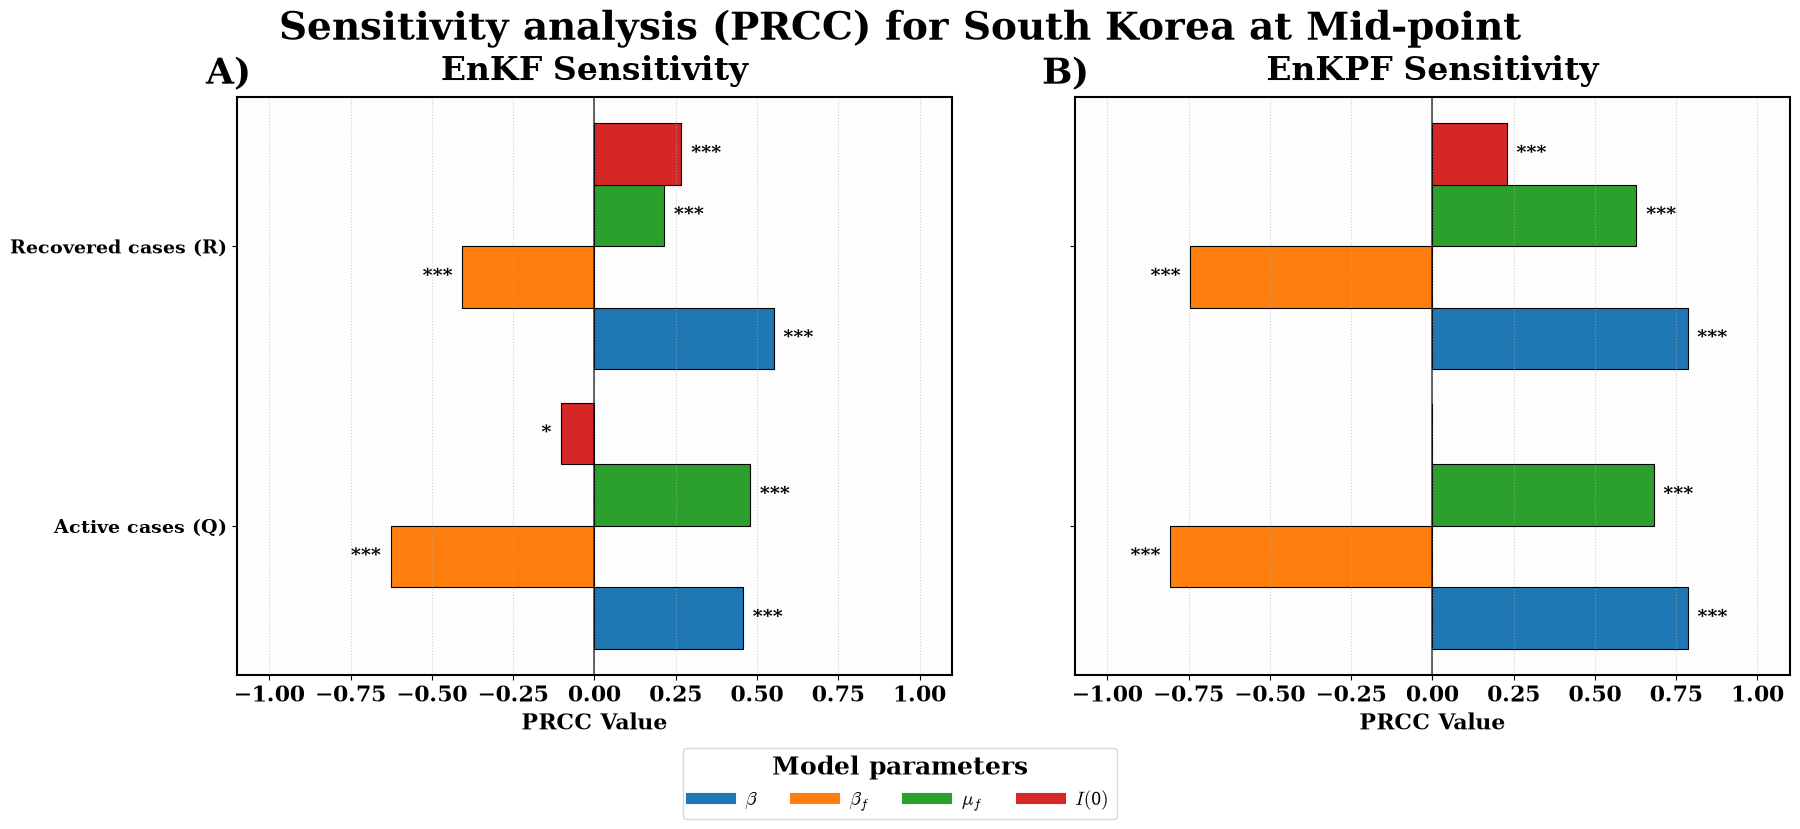


==================== South Korea Results ====================

PRCC Results for EnKF at Final Time (t=366):
Parameter  | Active cases (Q)     | Recovered cases (R) 
--------------------------------------------------------
beta       |  -0.3173 *** |   0.4844 *** | 
beta_f     |   0.9085 *** |  -0.8652 *** | 
mu_f       |  -0.9353 *** |   0.8902 *** | 
I(0)       |   0.1041 *   |  -0.1402 **  | 
Significance: * p<0.05, ** p<0.01, *** p<0.001

PRCC Results for EnKPF at Final Time (t=366):
Parameter  | Active cases (Q)     | Recovered cases (R) 
--------------------------------------------------------
beta       |  -0.2538 *** |   0.4577 *** | 
beta_f     |   0.9587 *** |  -0.9598 *** | 
mu_f       |  -0.9602 *** |   0.9557 *** | 
I(0)       |   0.0326     |  -0.0332     | 
Significance: * p<0.05, ** p<0.01, *** p<0.001


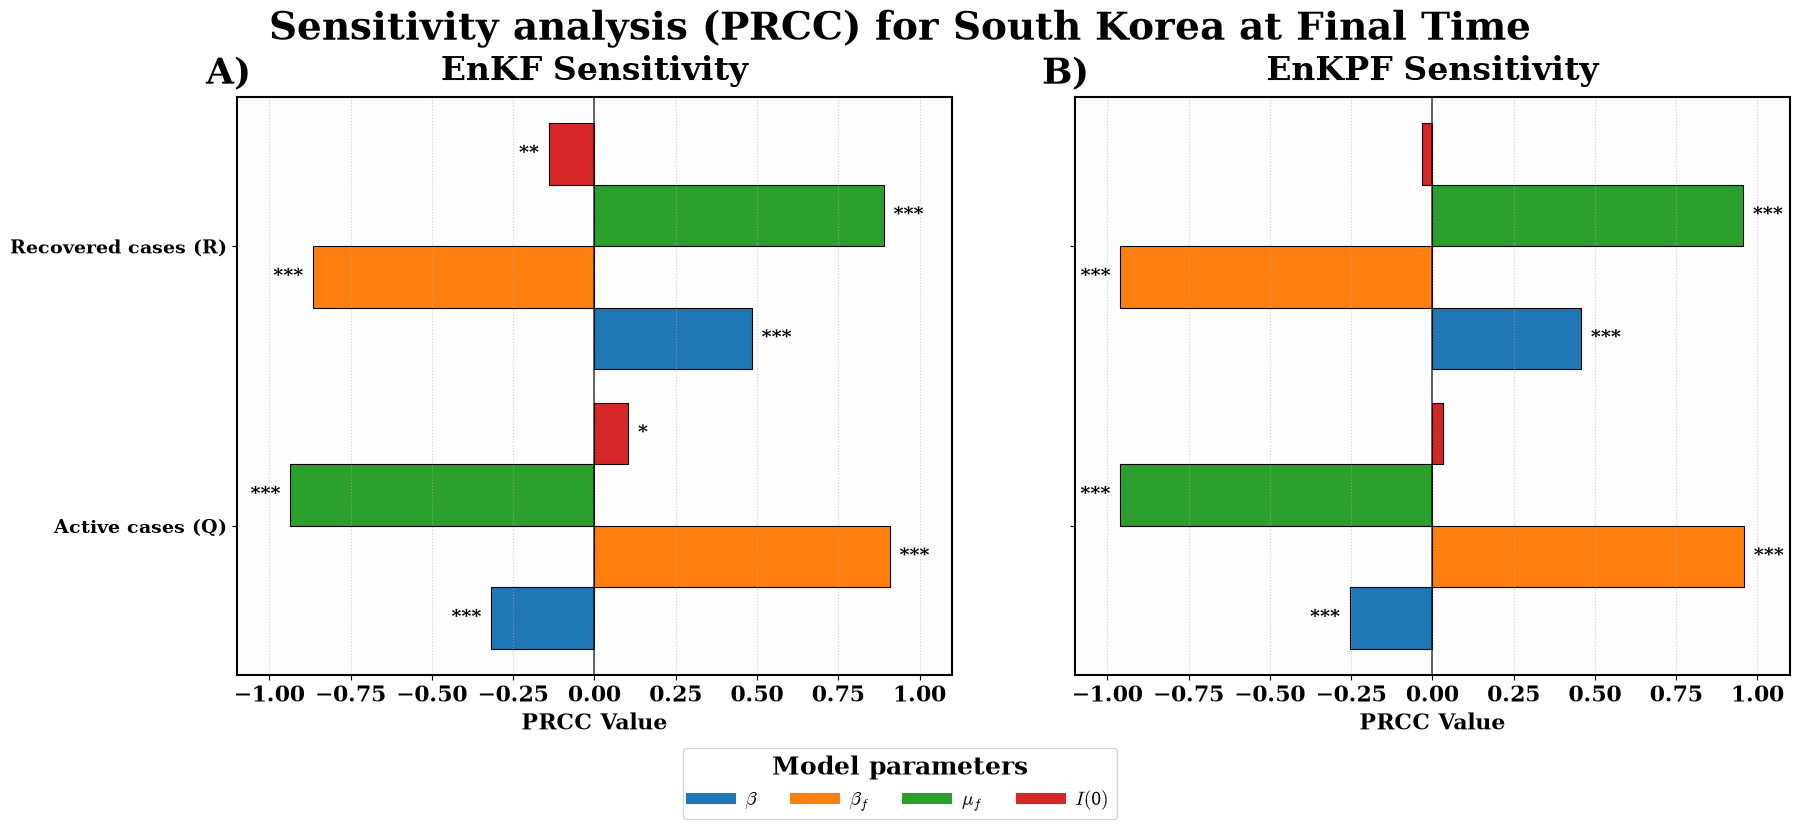


==================== Japan Results ====================

PRCC Results for EnKF at Mid-point (t=172):
Parameter  | Active cases (Q)     | Recovered cases (R) 
--------------------------------------------------------
beta       |   0.3146 *** |   0.4534 *** | 
beta_f     |  -0.8998 *** |  -0.9279 *** | 
mu_f       |   0.8875 *** |   0.9057 *** | 
I(0)       |   0.0303     |   0.1452 **  | 
Significance: * p<0.05, ** p<0.01, *** p<0.001

PRCC Results for EnKPF at Mid-point (t=172):
Parameter  | Active cases (Q)     | Recovered cases (R) 
--------------------------------------------------------
beta       |   0.4658 *** |   0.5889 *** | 
beta_f     |  -0.9758 *** |  -0.9788 *** | 
mu_f       |   0.9445 *** |   0.9429 *** | 
I(0)       |  -0.0053     |  -0.0024     | 
Significance: * p<0.05, ** p<0.01, *** p<0.001


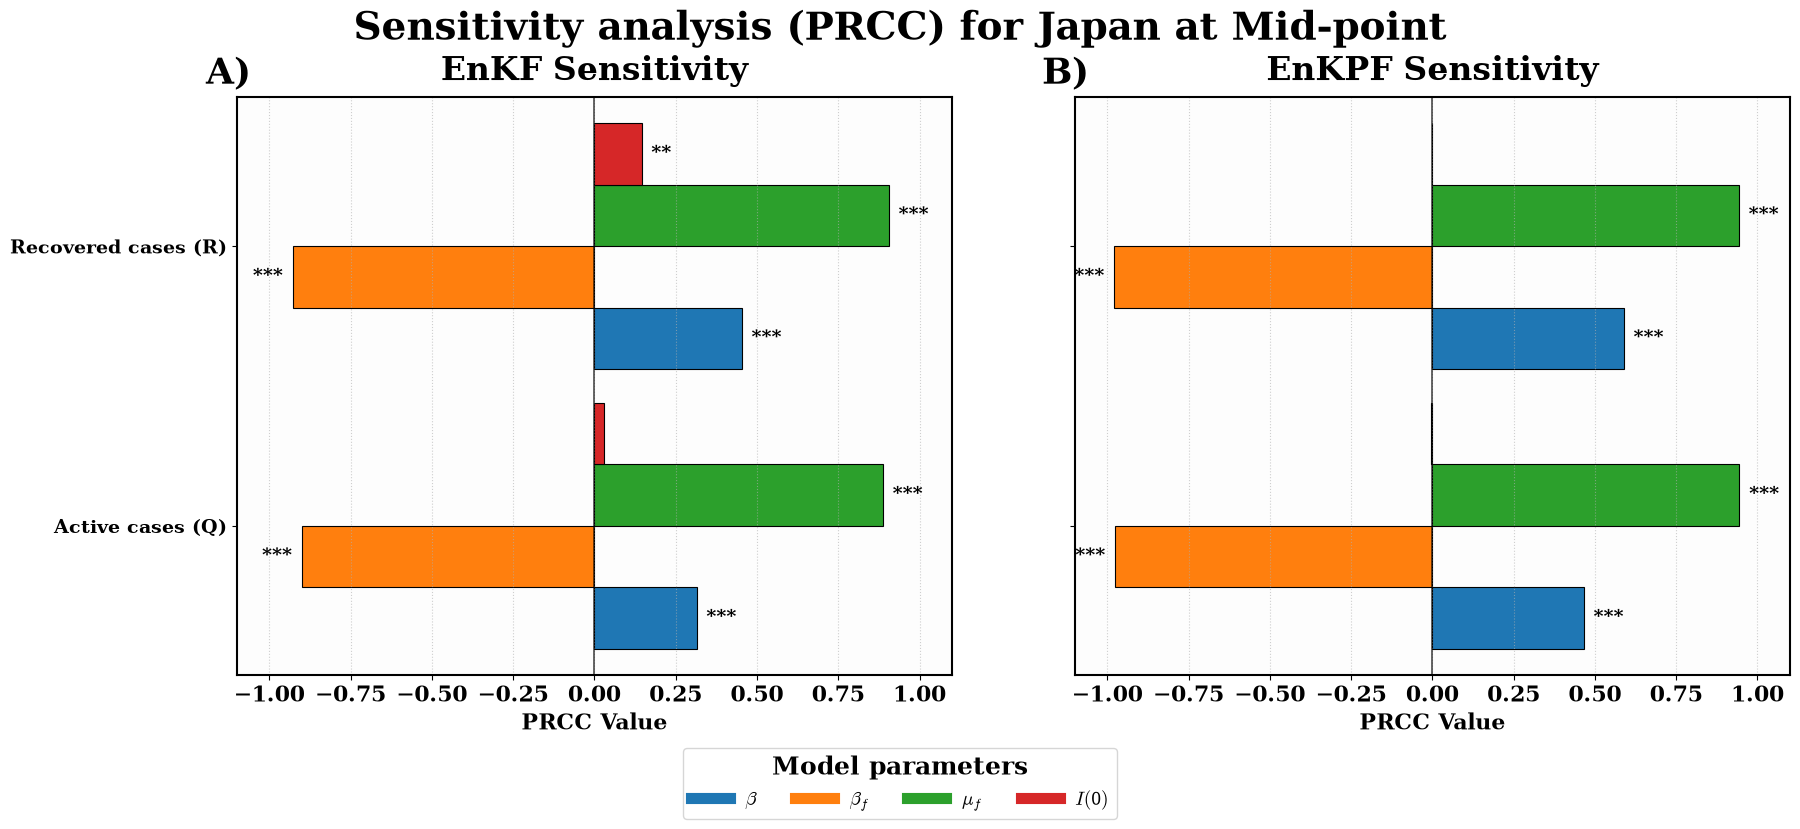


==================== Japan Results ====================

PRCC Results for EnKF at Final Time (t=343):
Parameter  | Active cases (Q)     | Recovered cases (R) 
--------------------------------------------------------
beta       |   0.0898 *   |   0.1645 *** | 
beta_f     |  -0.8319 *** |  -0.9995 *** | 
mu_f       |  -0.8519 *** |   0.8147 *** | 
I(0)       |  -0.0421     |   0.0099     | 
Significance: * p<0.05, ** p<0.01, *** p<0.001

PRCC Results for EnKPF at Final Time (t=343):
Parameter  | Active cases (Q)     | Recovered cases (R) 
--------------------------------------------------------
beta       |  -0.0563     |   0.1807 *** | 
beta_f     |  -0.8446 *** |  -0.9995 *** | 
mu_f       |  -0.8559 *** |   0.8164 *** | 
I(0)       |  -0.0456     |  -0.0129     | 
Significance: * p<0.05, ** p<0.01, *** p<0.001


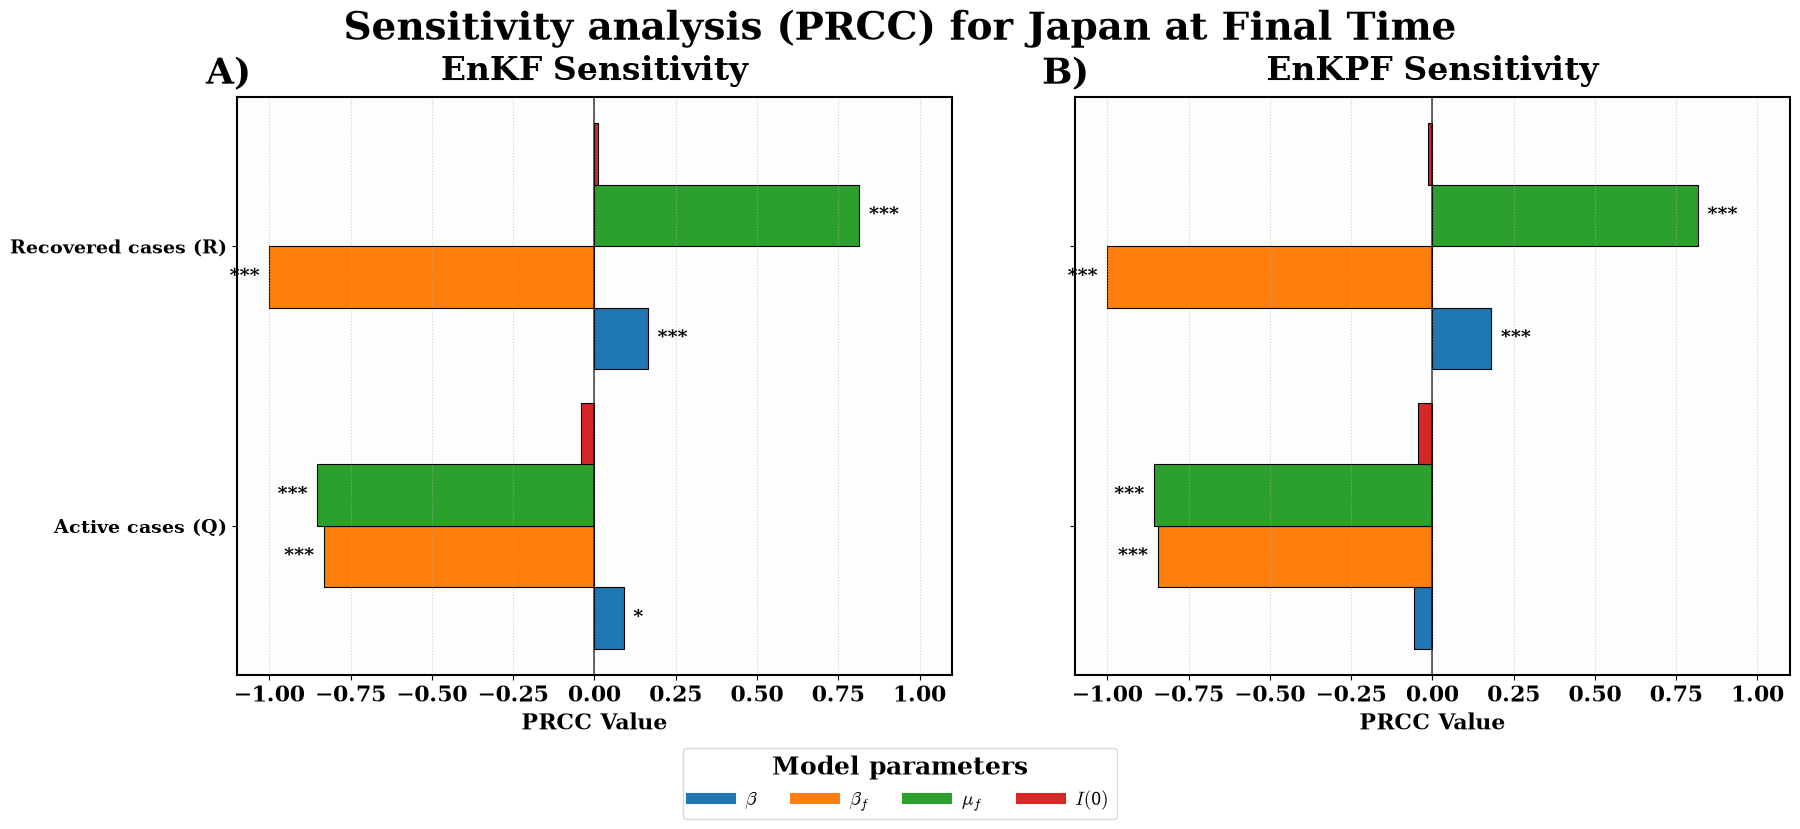


==================== Pakistan Results ====================

PRCC Results for EnKF at Mid-point (t=231):
Parameter  | Active cases (Q)     | Recovered cases (R) 
--------------------------------------------------------
beta       |  -0.3479 *** |   0.3959 *** | 
beta_f     |   0.8931 *** |  -0.8713 *** | 
mu_f       |  -0.8594 *** |   0.8480 *** | 
I(0)       |   0.0441     |  -0.0658     | 
Significance: * p<0.05, ** p<0.01, *** p<0.001

PRCC Results for EnKPF at Mid-point (t=231):
Parameter  | Active cases (Q)     | Recovered cases (R) 
--------------------------------------------------------
beta       |  -0.2046 *** |   0.2755 *** | 
beta_f     |   0.8336 *** |  -0.8728 *** | 
mu_f       |  -0.7479 *** |   0.8143 *** | 
I(0)       |   0.0606     |  -0.0883 *   | 
Significance: * p<0.05, ** p<0.01, *** p<0.001


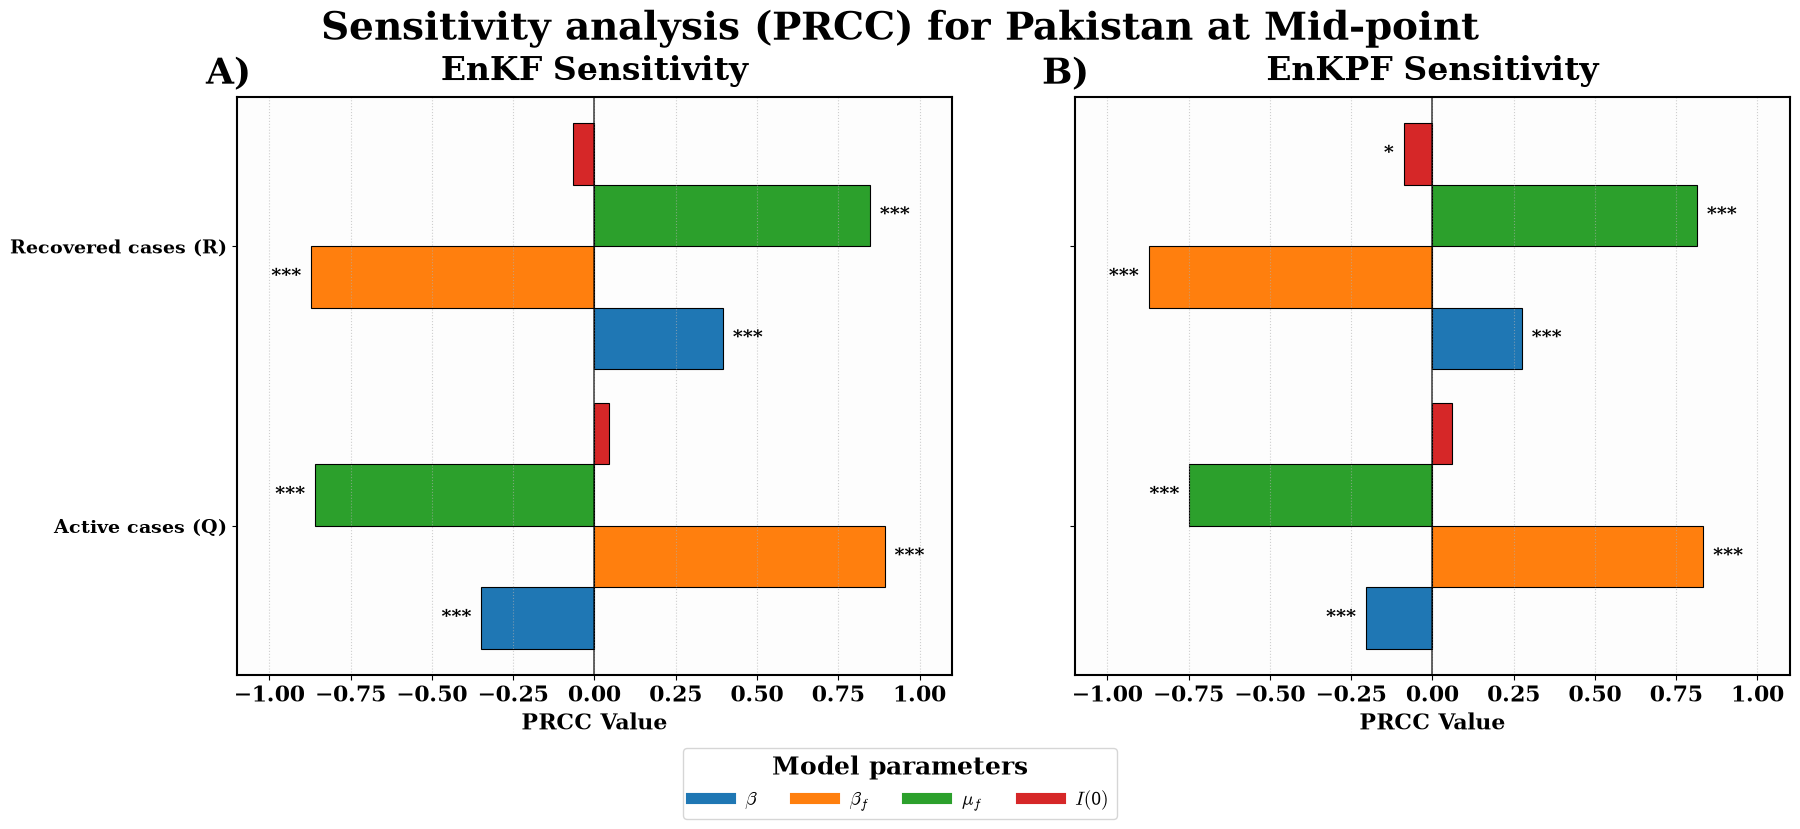


==================== Pakistan Results ====================

PRCC Results for EnKF at Final Time (t=462):
Parameter  | Active cases (Q)     | Recovered cases (R) 
--------------------------------------------------------
beta       |  -0.2718 *** |   0.5877 *** | 
beta_f     |   0.9153 *** |  -0.9266 *** | 
mu_f       |  -0.9451 *** |   0.9443 *** | 
I(0)       |   0.0500     |  -0.0512     | 
Significance: * p<0.05, ** p<0.01, *** p<0.001

PRCC Results for EnKPF at Final Time (t=462):
Parameter  | Active cases (Q)     | Recovered cases (R) 
--------------------------------------------------------
beta       |  -0.2058 *** |   0.4656 *** | 
beta_f     |   0.9467 *** |  -0.9505 *** | 
mu_f       |  -0.9562 *** |   0.9517 *** | 
I(0)       |   0.1259 **  |  -0.1214 **  | 
Significance: * p<0.05, ** p<0.01, *** p<0.001


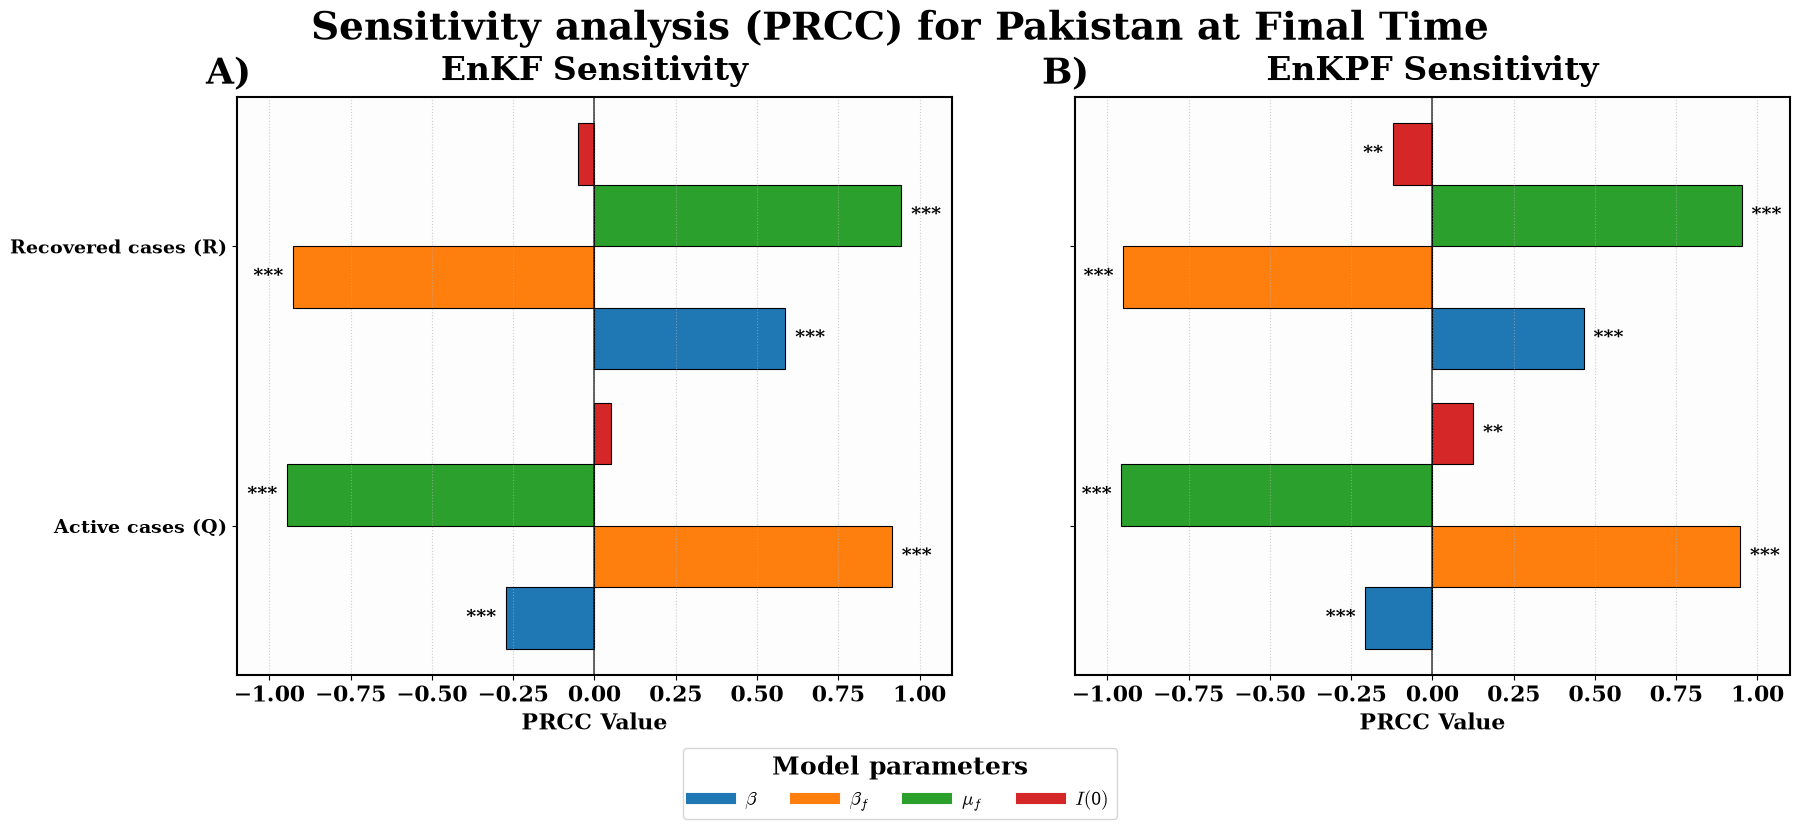

In [19]:

# Directory Setup
from typing import Any

# Country list matching your folder structure
COUNTRIES = [
    ("South Korea", DATA_DIR / "Korea"),
    ("Japan", DATA_DIR / "Japan"),
    ("Pakistan", DATA_DIR / "Pakistan"),
]

N_SAMPLES = 500
N_PARAMS = 4 
PARAM_NAMES = [r'$\beta$', r'$\beta_f$', r'$\mu_f$', r'$I(0)$']
PARAM_LABELS_PLAIN = ['beta', 'beta_f', 'mu_f', 'I(0)'] 
OUTPUT_NAMES = ['Active cases (Q)', 'Recovered cases (R)']
PARAM_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

np.random.seed(12345)

# --- Helper Functions ---

def _p_to_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    return ''

def calculate_prcc(X, Y):
    """Computes Partial Rank Correlation Coefficients (equivalent to MATLAB tiedrank/corr)."""
    n_samples, n_params = X.shape
    n_outputs = Y.shape[1]
    X_rank = np.array([rankdata(X[:, i]) for i in range(n_params)]).T
    Y_rank = np.array([rankdata(Y[:, j]) for j in range(n_outputs)]).T
    
    prcc = np.zeros((n_params, n_outputs))
    pvals = np.ones((n_params, n_outputs))
    for i in range(n_params):
        X_ex = np.delete(X_rank, i, axis=1)
        Z = np.column_stack([np.ones(n_samples), X_ex])
        b1 = np.linalg.lstsq(Z, X_rank[:, i], rcond=None)[0]
        res1 = X_rank[:, i] - Z.dot(b1)
        for j in range(n_outputs):
            b2 = np.linalg.lstsq(Z, Y_rank[:, j], rcond=None)[0]
            res2 = Y_rank[:, j] - Z.dot(b2)
           
            res: Any = pearsonr(res1, res2)
            prcc[i, j] = float(res[0])
            pvals[i, j] = float(res[1])
    return prcc, pvals

def print_results_table(method, time_label, t_idx, prcc, pvals):
    """Prints results to console in the MATLAB format."""
    print(f"\nPRCC Results for {method} at {time_label} (t={t_idx}):")
    header = f"{'Parameter':<10} | {OUTPUT_NAMES[0]:<20} | {OUTPUT_NAMES[1]:<20}"
    print(header)
    print("-" * len(header))
    for i in range(N_PARAMS):
        row = f"{PARAM_LABELS_PLAIN[i]:<10} | "
        for j in range(2):
            star = _p_to_stars(pvals[i, j])
            row += f"{prcc[i, j]:8.4f} {star:<3} | "
        print(row)
    print("Significance: * p<0.05, ** p<0.01, *** p<0.001")

def modeleq_py(t, x, params):
    """ODE Model translation."""
    # Parameters as defined in your model
    Lambda, mu, rbeta, gamma, alpha, mmu, delta = (5.9/1000)*(1/365), (5.7/1000)*(1/365), 0.02, 1/4, 1/14, 0.0221, 1/1000
    N, S, I, Q, R = x[0], x[1], x[2], x[3], x[4]
    Sf = N - (S + I + Q + R)
    beta, betaf, muf = params[0], params[1], params[2]
    
    dx = np.zeros(9)
    dx[0] = Lambda*N - mu*N - mmu*Q
    dx[1] = Lambda*N - (beta*S*I/N) - betaf*S*(1-np.exp(-delta*Q)) + (muf*Sf*(S+R)/N) - mu*S
    dx[2] = (beta*S*I/N) + (rbeta*beta*Sf*I/N) - (gamma+mu)*I
    dx[3] = gamma*I - (mu + alpha + mmu)*Q
    dx[4] = alpha*Q - mu*R
    return dx

# --- Main Analysis Loop ---

for country_name, folder_path in COUNTRIES:
    mat_file = folder_path / f"{folder_path.name}Data.mat"
    if not mat_file.exists():
        print(f"Skipping {country_name}: File not found.")
        continue
    
    # Load Data
    mat = loadmat(mat_file)
    x_hat = mat['x_hat_combined']
    x_hatenkfp = mat['x_hatenkfP_combined']
    P = mat['P_combined']
    Penkfp = mat['PenkfP_combined']
    
    n_time = x_hat.shape[1]
    time_points = [n_time // 2, n_time - 1]
    param_indices = np.arange(x_hat.shape[0] - N_PARAMS, x_hat.shape[0])

    for t_idx in time_points:
        time_label = "Mid-point" if t_idx == n_time // 2 else "Final Time"
        
        # Sampling
        def get_samples(mu_vec, cov_mat):
            C = (cov_mat + cov_mat.T) / 2 + 1e-6 * np.eye(N_PARAMS)
            return np.maximum(np.random.multivariate_normal(mu_vec, C, N_SAMPLES), 0)

        samples_en = get_samples(x_hat[param_indices, t_idx], P[np.ix_(param_indices, param_indices, [t_idx])].squeeze())
        samples_ep = get_samples(x_hatenkfp[param_indices, t_idx], Penkfp[np.ix_(param_indices, param_indices, [t_idx])].squeeze())

        # Model Simulation
        outputs_en = np.zeros((N_SAMPLES, 2))
        outputs_ep = np.zeros((N_SAMPLES, 2))
        x0_base = x_hat[:9, 0].astype(float)

        for i in range(N_SAMPLES):
            # EnKF
            p_en = samples_en[i, :]; x0_en = x0_base.copy(); x0_en[2] = p_en[3]
            sol_en = solve_ivp(lambda t, y: modeleq_py(t, y, p_en), (0, t_idx), x0_en, t_eval=[t_idx])
            if sol_en.success: outputs_en[i, :] = sol_en.y[3:5, -1]
            
            # EnKPF
            p_ep = samples_ep[i, :]; x0_ep = x0_base.copy(); x0_ep[2] = p_ep[3]
            sol_ep = solve_ivp(lambda t, y: modeleq_py(t, y, p_ep), (0, t_idx), x0_ep, t_eval=[t_idx])
            if sol_ep.success: outputs_ep[i, :] = sol_ep.y[3:5, -1]

        # Calculate PRCC
        prcc_en, pvals_en = calculate_prcc(samples_en, outputs_en)
        prcc_ep, pvals_ep = calculate_prcc(samples_ep, outputs_ep)

        # 1. PRINT TABLES (MATLAB STYLE)
        print(f"\n{'='*20} {country_name} Results {'='*20}")
        print_results_table("EnKF", time_label, t_idx, prcc_en, pvals_en)
        print_results_table("EnKPF", time_label, t_idx, prcc_ep, pvals_ep)

        # 2. SAVE CSVs
        for method, p_data, v_data in [('enkf', prcc_en, pvals_en), ('enkfp', prcc_ep, pvals_ep)]:
            df = pd.DataFrame({
                'Parameter': PARAM_LABELS_PLAIN,
                'PRCC_Active': p_data[:, 0], 'p_Active': v_data[:, 0],
                'PRCC_Recovered': p_data[:, 1], 'p_Recovered': v_data[:, 1]
            })
            df.to_csv(OUTPUT_DIR / f'PRCC_{country_name}_{method}_t{t_idx}.csv', index=False)

        # 3. PLOT PANEL
        fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
        fig.set_constrained_layout_pads(  # type: ignore[attr-defined]
                w_pad=0.1,
                h_pad=0.1,
                hspace=0.1,
                wspace=0.1,
            )
       # fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.1, hspace=0.1, wspace=0.1)
        
        plot_data = [('EnKF Sensitivity', prcc_en, pvals_en, 'A)'), 
                     ('EnKPF Sensitivity', prcc_ep, pvals_ep, 'B)')]

        for col, (title, data, pvals, tag) in enumerate(plot_data):
            ax = axes[col]
            y_pos = np.arange(len(OUTPUT_NAMES))
            height = 0.22 

            for i in range(N_PARAMS):
                offset = (i - (N_PARAMS - 1) / 2) * height
                ax.barh(y_pos + offset, data[i, :], height=height,
                        color=PARAM_COLORS[i], label=PARAM_NAMES[i],
                        edgecolor='black', linewidth=0.8)

                for j in range(2):
                    star = _p_to_stars(pvals[i, j])
                    if star:
                        val = data[i, j]
                        ha = 'left' if val >= 0 else 'right'
                        ax.text(val + (0.03 if val >= 0 else -0.03), y_pos[j] + offset, 
                                star, va='center', ha=ha, fontsize=14, fontweight='bold')

            ax.set_yticks(y_pos)
            ax.set_yticklabels(OUTPUT_NAMES if col == 0 else [], fontsize=14, fontweight='bold')
            ax.set_xlim([-1.1, 1.1])
            ax.set_xlabel('PRCC Value', fontsize=16, fontweight='bold')
            ax.set_title(title, fontsize=24, fontweight='bold', pad=12, loc='center')
            ax.text(0.02, 1.07, tag, transform=ax.transAxes, fontsize=26, fontweight='bold', va='top', ha='right')
            ax.axvline(0, color='black', lw=1.2, alpha=0.7)
            ax.grid(axis='x', linestyle=':', alpha=0.6)
            ax.set_facecolor('#fdfdfd')

        fig.suptitle(f'Sensitivity analysis (PRCC) for {country_name} at {time_label}', 
                     fontsize=28, fontweight='bold', y=1.05)

        legend_els = [Line2D([0], [0], color=PARAM_COLORS[i], lw=8, label=PARAM_NAMES[i]) for i in range(N_PARAMS)]
        fig.legend(handles=legend_els, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.12),
                   fontsize=14, title='Model parameters', title_fontsize=18, frameon=True)

        plt.savefig(OUTPUT_DIR / f'PRCC_Panel_{country_name}_{t_idx}.png', dpi=600, bbox_inches='tight')
        plt.show()

In [20]:
# Compute hold-out (20%) MSE, chi-square (using predicted variances), and R^2 for Q and R
# Uses x_hat_combined / P_combined (EnKF) and x_hatenkfP_combined / PenkfP_combined (EnKPF)
# Assumption: hold-out = last 20% of the time points (contiguous tail of the series)
import pandas as pd
from scipy.stats import chi2
from scipy.io import loadmat
import numpy as np

# Local r2_score fallback
try:
    from sklearn.metrics import r2_score
except Exception:
    def r2_score(y_true, y_pred):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        if ss_tot == 0:
            return np.nan
        return 1.0 - ss_res / ss_tot

# Local helper in case percent_reduction isn't defined in current kernel
def percent_reduction(mse_baseline, mse_new):
    return 100.0 * (mse_baseline - mse_new) / mse_baseline if mse_baseline != 0 else np.nan

results = []
for country, folder in [('South Korea', 'Korea'), ('Japan', 'Japan'), ('Pakistan', 'Pakistan')]:
    try:
        mat = loadmat(DATA_DIR / folder / f'{folder}Data.mat')
    except Exception as e:
        print(f"Warning: cannot load MAT for {country}: {e}")
        continue

    # Required arrays
    x_hat = mat['x_hat_combined']
    x_hatenkfP = mat['x_hatenkfP_combined']
    P = mat['P_combined']
    P_enkfp = mat['PenkfP_combined']
    z = mat['z_combined']

    if any(arr is None for arr in (x_hat, x_hatenkfP, P, P_enkfp, z)):
        print(f"Skipping {country} (missing required arrays)")
        continue

    n = x_hat.shape[1]
    hold_n = max(1, int(np.ceil(0.20 * n)))
    # Use last 20% as hold-out
    start = n - hold_n
    idx = np.arange(start, n)

    for compartment_idx, label in [(4, 'Q'), (5, 'R')]:
        # Observed vector: z rows are indexed by (compartment_idx - 4) as in other cells
        obs = np.asarray(z[compartment_idx - 4, :]).flatten()
        en_mean = np.asarray(x_hat[compartment_idx - 1, :]).flatten()
        en_var = np.asarray(P[compartment_idx - 1, compartment_idx - 1, :]).flatten()
        ep_mean = np.asarray(x_hatenkfP[compartment_idx - 1, :]).flatten()
        ep_var = np.asarray(P_enkfp[compartment_idx - 1, compartment_idx - 1, :]).flatten()

        L = min(len(obs), len(en_mean), len(en_var), len(ep_mean), len(ep_var))
        if L <= 0:
            print(f"No data for {country} {label}")
            continue
        # Adjust indices if arrays shorter
        idx_local = np.arange(max(0, L - hold_n), L)

        obs_h = obs[idx_local]
        en_mean_h = en_mean[idx_local]
        ep_mean_h = ep_mean[idx_local]
        en_var_h = en_var[idx_local].copy(); en_var_h[en_var_h <= 0] = 1e-8
        ep_var_h = ep_var[idx_local].copy(); ep_var_h[ep_var_h <= 0] = 1e-8

        # Metrics
        mse_en = np.mean((obs_h - en_mean_h) ** 2)
        mse_ep = np.mean((obs_h - ep_mean_h) ** 2)
        pct_reduction = percent_reduction(mse_en, mse_ep)

        # Chi-square using predicted variances (sum over hold-out)
        chi2_en = float(np.sum((obs_h - en_mean_h) ** 2 / en_var_h))
        chi2_ep = float(np.sum((obs_h - ep_mean_h) ** 2 / ep_var_h))
        df = max(1, len(obs_h) - 1)
        p_en = chi2.sf(chi2_en, df)
        p_ep = chi2.sf(chi2_ep, df)

        r2_en = r2_score(obs_h, en_mean_h)
        r2_ep = r2_score(obs_h, ep_mean_h)

        results.append({
            'country': country,
            'compartment': label,
            'n_hold': len(obs_h),
            'mse_enkf': mse_en,
            'mse_enkpf': mse_ep,
            'pct_mse_reduction_enkpf_vs_enkf': pct_reduction,
            'chi2_enkf': chi2_en,
            'p_enkf': p_en,
            'chi2_enkpf': chi2_ep,
            'p_enkpf': p_ep,
            'r2_enkf': r2_en,
            'r2_enkpf': r2_ep,
        })

# Save results
df_res = pd.DataFrame(results)
if not df_res.empty:
    savep = OUTPUT_DIR / 'holdout_metrics_by_country_compartment.csv'
    df_res.to_csv(savep, index=False)
    print(f"Saved hold-out metrics to: {savep}")
print(df_res)


Saved hold-out metrics to: c:\Users\ABBASWASIM\OneDrive - pnu.ac.kr\2025\matlab\SAJIDA papers\paper work poisson_enkf_enkpf\Final\writing\ipynb_bundle\Figures2\holdout_metrics_by_country_compartment.csv
       country compartment  n_hold      mse_enkf      mse_enkpf  \
0  South Korea           Q      74  9.817132e+03   11659.400290   
1  South Korea           R      74  1.149788e+05    7868.635345   
2        Japan           Q      69  1.677716e+05  175484.042664   
3        Japan           R      69  2.237171e+06  216307.664057   
4     Pakistan           Q      93  1.800073e+05  653641.167065   
5     Pakistan           R      93  2.200478e+07  780688.970905   

   pct_mse_reduction_enkpf_vs_enkf  chi2_enkf  p_enkf  chi2_enkpf  p_enkpf  \
0                       -18.765854   0.475613     1.0    7.341099      1.0   
1                        93.156444   0.340111     1.0    5.737153      1.0   
2                        -4.596978   0.422176     1.0    4.838175      1.0   
3              

In [22]:
# Compare hold-out RMSE (sqrt(MSE)) with MATLAB RMSE arrays saved in the .mat files
# This will help explain the discrepancy noted by the user
import numpy as np
from math import sqrt

def _first_existing(matdict, keys):
    for k in keys:
        v = matdict.get(k)
        if v is not None:
            return v
    return None

compare_rows = []
for country, folder in [('South Korea', 'Korea'), ('Japan', 'Japan'), ('Pakistan', 'Pakistan')]:
    try:
        mat = loadmat(DATA_DIR / folder / f'{folder}Data.mat')
    except Exception as e:
        print(f"Warning: cannot load MAT for {country}: {e}")
        continue

    # get obs and predictions as in the holdout cell
    z = mat['z_combined']
    x_hat = mat['x_hat_combined']
    x_hatenkfP = mat['x_hatenkfP_combined']

    if any(arr is None for arr in (z, x_hat, x_hatenkfP)):
        print(f"Skipping {country} (missing arrays)")
        continue

    n = x_hat.shape[1]
    hold_n = max(1, int(np.ceil(0.20 * n)))
    L = n
    idx_local = np.arange(max(0, L - hold_n), L)

    for compartment_idx, label in [(4, 'Q'), (5, 'R')]:
        obs = np.asarray(z[compartment_idx - 4, :]).flatten()
        en_mean = np.asarray(x_hat[compartment_idx - 1, :]).flatten()
        ep_mean = np.asarray(x_hatenkfP[compartment_idx - 1, :]).flatten()

        obs_h = obs[idx_local]
        en_mean_h = en_mean[idx_local]
        ep_mean_h = ep_mean[idx_local]

        rmse_en = float(np.sqrt(np.mean((obs_h - en_mean_h) ** 2)))
        rmse_ep = float(np.sqrt(np.mean((obs_h - ep_mean_h) ** 2)))

        # Find MATLAB RMSE arrays (try multiple possible names used in scripts)
        if label == 'Q':
            mat_enkf = _first_existing(mat, ['RMS_Q1', 'RMS_Q', 'RMS_Q1'])
            mat_enkfp = _first_existing(mat, ['RMS_Q_enkfP1', 'RMS_Q_enkfP', 'RMS_Q_enkfP1'])
        else:
            mat_enkf = _first_existing(mat, ['RMS_R1', 'RMS_R', 'RMS_R1'])
            mat_enkfp = _first_existing(mat, ['RMS_R_enkfP1', 'RMS_R_enkfP', 'RMS_R_enkfP1'])

        # Extract last value from MATLAB arrays if present
        mat_rmse_en = float(mat_enkf.flatten()[-1]) if isinstance(mat_enkf, np.ndarray) else np.nan
        mat_rmse_ep = float(mat_enkfp.flatten()[-1]) if isinstance(mat_enkfp, np.ndarray) else np.nan

        compare_rows.append({
            'country': country,
            'compartment': label,
            'rmse_hold_enkf': rmse_en,
            'rmse_hold_enkpf': rmse_ep,
            'mat_rmse_enkf_last': mat_rmse_en,
            'mat_rmse_enkpf_last': mat_rmse_ep,
            'diff_hold_mat_enkf': rmse_en - mat_rmse_en,
            'diff_hold_mat_enkpf': rmse_ep - mat_rmse_ep,
        })

cmp_df = pd.DataFrame(compare_rows)
print(cmp_df)
cmp_df.to_csv(OUTPUT_DIR / 'rmse_hold_vs_matlab_rmse.csv', index=False)
print('Saved comparison to rmse_hold_vs_matlab_rmse.csv')

       country compartment  rmse_hold_enkf  rmse_hold_enkpf  \
0  South Korea           Q       99.081440       107.978703   
1  South Korea           R      339.085170        88.705329   
2        Japan           Q      409.599339       418.908155   
3        Japan           R     1495.717409       465.088878   
4     Pakistan           Q      424.272699       808.480777   
5     Pakistan           R     4690.925637       883.566054   

   mat_rmse_enkf_last  mat_rmse_enkpf_last  diff_hold_mat_enkf  \
0           28.735304            13.623093           70.346136   
1           67.756303            14.907099          271.328868   
2           51.632760            16.730075          357.966578   
3           70.611407            16.764039         1425.106002   
4          461.003656           257.420106          -36.730956   
5         1216.067398           271.571701         3474.858239   

   diff_hold_mat_enkpf  
0            94.355610  
1            73.798230  
2           402.1780

In [21]:
# Compute full-series RMSE and percent reduction (EnKPF vs EnKF) using the same x_hat/x_hatenkfP and z
full_rows = []
for country, folder in [('South Korea', 'Korea'), ('Japan', 'Japan'), ('Pakistan', 'Pakistan')]:
    try:
        mat = loadmat(DATA_DIR / folder / f'{folder}Data.mat')
    except Exception as e:
        print(f"Warning: cannot load MAT for {country}: {e}")
        continue

    z = mat['z_combined']
    x_hat = mat['x_hat_combined']
    x_hatenkfP = mat['x_hatenkfP_combined']
    if any(arr is None for arr in (z, x_hat, x_hatenkfP)):
        print(f"Skipping {country} (missing arrays)")
        continue

    for compartment_idx, label in [(4, 'Q'), (5, 'R')]:
        obs = np.asarray(z[compartment_idx - 4, :]).flatten()
        en_mean = np.asarray(x_hat[compartment_idx - 1, :]).flatten()
        ep_mean = np.asarray(x_hatenkfP[compartment_idx - 1, :]).flatten()

        rmse_total_en = float(np.sqrt(np.mean((obs - en_mean) ** 2)))
        rmse_total_ep = float(np.sqrt(np.mean((obs - ep_mean) ** 2)))
        pct_red_total = percent_reduction(rmse_total_en, rmse_total_ep)

        full_rows.append({
            'country': country,
            'compartment': label,
            'rmse_total_enkf': rmse_total_en,
            'rmse_total_enkpf': rmse_total_ep,
            'pct_rmse_reduction_enkpf_vs_enkf': pct_red_total,
        })

full_df = pd.DataFrame(full_rows)
print(full_df)
full_df.to_csv(OUTPUT_DIR / 'rmse_fullseries_enkpf_vs_enkf.csv', index=False)
print('Saved full-series RMSE comparison to rmse_fullseries_enkpf_vs_enkf.csv')

       country compartment  rmse_total_enkf  rmse_total_enkpf  \
0  South Korea           Q        50.833511         52.759512   
1  South Korea           R       177.799085         45.423653   
2        Japan           Q       196.299830        201.516700   
3        Japan           R       755.050364        221.168528   
4     Pakistan           Q       403.944410        471.929318   
5     Pakistan           R      2771.640016        571.779246   

   pct_rmse_reduction_enkpf_vs_enkf  
0                         -3.788841  
1                         74.452257  
2                         -2.657603  
3                         70.708109  
4                        -16.830263  
5                         79.370364  
Saved full-series RMSE comparison to rmse_fullseries_enkpf_vs_enkf.csv
